<img width="200" style="float:left" 
     src="https://upload.wikimedia.org/wikipedia/commons/f/f3/Apache_Spark_logo.svg" />

# Apache Spark Group Project - Earthquake Data - Risk analysis

<a id='0'></a>
## Description
This project has a few objectives:
  
* Build a DataFrame from multiple JSON files.
* Handle some data that's a bit more complex, like arrays of JSON documents.
* Handling variety of data in json and csv format
* Run some simple calculations and analysis on the data.


## Overarching Business Question

***"How should a real estate agency use seismic data to make smarter property acquisition and portfolio decisions?"***

Earthquake exposure is one of the most underestimated risks in real estate — it affects property valuations, insurance costs, and portfolio concentration in ways that traditional market analysis overlooks. This notebook builds a seismic risk intelligence platform that supports data-driven decision-making across the full property acquisition lifecycle.

Each step answers a different dimension of this question:

| Step | Technique | Decision Supported |
|------|-----------|-------------------|
| **Step 1** – Batch Processing | Risk Index (40% frequency + 60% severity) | **Market Scoring:** Which markets carry the highest seismic risk and how does that affect property value? |
| **Step 2** – Structured Streaming | 5-min tumbling windows, watermarking | **Live Monitoring:** Is seismic activity changing near a property we're evaluating right now? |
| **Step 3** – Graph Processing | PageRank, degree analysis, motif finding | **Portfolio Risk:** Are two properties in our portfolio exposed to the same seismic corridor? |
| **Step 4** – Machine Learning | KMeans clustering with PCA | **Risk Classification:** How do we objectively group our properties into risk tiers for insurance and planning? |

Together, the platform enables a real estate agency to **score markets, monitor targets in real time, avoid hidden portfolio concentration, and classify properties into data-driven risk tiers** — replacing guesswork with seismic intelligence.

### ⚙️ One-Time Setup

The cell below installs **GraphFrames** (needed for Step 3). **Run it once**, then **restart the kernel** before proceeding. On subsequent runs, skip this cell.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# RUN THIS CELL ONCE (first time only), then RESTART THE KERNEL
# ══════════════════════════════════════════════════════════════════════
import subprocess, sys, os

# 1. Install GraphFrames Python package
subprocess.check_call([sys.executable, "-m", "pip", "install", "graphframes", "--quiet"])

# 2. Download the GraphFrames JAR
subprocess.check_call(["wget", "-q", "-P", "/tmp/",
    "https://repos.spark-packages.org/graphframes/graphframes/0.8.3-spark3.5-s_2.12/graphframes-0.8.3-spark3.5-s_2.12.jar"])

# 3. Copy JAR into PySpark's jars folder so Spark loads it at startup
import pyspark
jars_path = os.path.join(os.path.dirname(pyspark.__file__), "jars")
subprocess.check_call(["cp", "/tmp/graphframes-0.8.3-spark3.5-s_2.12.jar", jars_path])

print("GraphFrames installed ✓")
print("⚠️  NOW RESTART THE KERNEL (Kernel → Restart) and then run all cells from the next cell onward.")
print("⚠️  You only need to run this cell ONCE — skip it on future runs.")

We're going to use **Pandas** to make our results **look much better**. Let's set it up first:

In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

**It's time to create the [Spark Session](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.SparkSession.html)** before we can do any other thing. Remember, the Spark Session *is the entry point to programming Spark with the DataFrame API (High-level API)*.

In [2]:
from pyspark.sql.session import SparkSession

spark_session = \
  SparkSession.builder\
              .appName("Earthquake analysis")\
              .getOrCreate()

print(f"This cluster relies on Spark '{spark_session.version}'")

26/03/16 19:01:14 WARN Utils: Your hostname, osbdet resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
26/03/16 19:01:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 19:01:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


This cluster relies on Spark '3.5.4'


26/03/16 19:01:43 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


<a id='2'></a>
## Step 1 - Ingest Earthquake data into MinIO
We're going to use a NiFi flow to grab Earthquake data from USGS every 5 minutes. It'll ingest all that info into **the earthquake bucket which we created in MinIO**, ready for Spark to analyze later. The data will be in the **[JSON](https://jsonlines.org/)** lines format Spark knows how to use.

<a id='2.2'></a>
### NiFi flow import

1. **Download** the `Earthquake_info_to_MinIO_(S3).json` attached in the submission
2. **Access** the [Apache NiFi UI](http://localhost:29090/nifi/)
3. **Create a new Process Group** from the JSON file containing the NiFi flow
4. Call it **`Earthquake info to MinIO (S3)`**
5. **Confirm the creation**.
6. Deal with the import warning sign

We're almost there! We need to remove the warning message to be able to move forward; that will be accomplished via **adding the credentials to let NiFi access MinIO**

*Double click the Process Group to access its contents* and configure the **"Controller Services"** (*Right-click the canvas, then click Controller Services*):

Edit the `AWSCredentialsProviderControllerService` Controller Service configure the following two parameters:

- **Access Key ID:** s3access 
- **Secret Access Key:** _s3access123$


<a id='3.1'></a>
### DataFrame creation

We need to tell the Spark Session **how to access MinIO**, our *S3 compatible object store*:

In [3]:
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.access.key", "s3access")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.secret.key", "_s3access123$")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.path.style.access", "true")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.endpoint", "http://localhost:9000")

We are now ready to **create the DataFrame on top of the data in MinIO**, which will allow us to *start with the Exploratory Data Analysis*:

In [4]:
from pyspark.sql.functions import input_file_name

earthquake_raw_df = spark_session.read\
                                .json("s3a://earthquake/earthquakes_*.json")

# DataFrame updated with an additional column containing the filename contributing to the data in every row.
earthquake_raw_df = earthquake_raw_df.withColumn("filename_path", input_file_name())

# The inferred schema can be visualized using the printSchema() method - definitely semi-structured data.
earthquake_raw_df.printSchema()

26/03/16 19:02:18 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties
26/03/16 19:02:18 WARN VersionInfoUtils: The AWS SDK for Java 1.x entered maintenance mode starting July 31, 2024 and will reach end of support on December 31, 2025. For more information, see https://aws.amazon.com/blogs/developer/the-aws-sdk-for-java-1-x-is-in-maintenance-mode-effective-july-31-2024/
You can print where on the file system the AWS SDK for Java 1.x core runtime is located by setting the AWS_JAVA_V1_PRINT_LOCATION environment variable or aws.java.v1.printLocation system property to 'true'.
This message can be disabled by setting the AWS_JAVA_V1_DISABLE_DEPRECATION_ANNOUNCEMENT environment variable or aws.java.v1.disableDeprecationAnnouncement system property to 'true'.
The AWS SDK for Java 1.x is being used here:
at java.base/java.lang.Thread.getStackTrace(Thread.java:2451)
at com.amazonaws.util.VersionInfoUtils.printDeprecationAn

root
 |-- _corrupt_record: string (nullable = true)
 |-- api: string (nullable = true)
 |-- count: long (nullable = true)
 |-- generated: long (nullable = true)
 |-- geometry: struct (nullable = true)
 |    |-- coordinates: array (nullable = true)
 |    |    |-- element: double (containsNull = true)
 |    |-- type: string (nullable = true)
 |-- id: string (nullable = true)
 |-- properties: struct (nullable = true)
 |    |-- alert: string (nullable = true)
 |    |-- cdi: double (nullable = true)
 |    |-- code: string (nullable = true)
 |    |-- detail: string (nullable = true)
 |    |-- dmin: double (nullable = true)
 |    |-- felt: long (nullable = true)
 |    |-- gap: double (nullable = true)
 |    |-- ids: string (nullable = true)
 |    |-- mag: double (nullable = true)
 |    |-- magType: string (nullable = true)
 |    |-- mmi: double (nullable = true)
 |    |-- net: string (nullable = true)
 |    |-- nst: long (nullable = true)
 |    |-- place: string (nullable = true)
 |    |-- rm

Let's display the ***last 10 files contributing to the DataFrame***:

In [5]:
from  pyspark.sql.functions import col

earthquake_raw_df.select("filename_path")\
                .distinct()\
                .orderBy(col("filename_path").desc())\
                .limit(10)\
                .toPandas()

,filename_path
0,s3a://earthquake/earthquakes_20260316_1901.json
1,s3a://earthquake/earthquakes_20260316_1856.json
2,s3a://earthquake/earthquakes_20260316_1850.json
3,s3a://earthquake/earthquakes_20260316_1845.json
4,s3a://earthquake/earthquakes_20260316_1840.json
5,s3a://earthquake/earthquakes_20260316_1835.json
6,s3a://earthquake/earthquakes_20260316_1830.json
7,s3a://earthquake/earthquakes_20260316_1825.json
8,s3a://earthquake/earthquakes_20260316_1820.json
9,s3a://earthquake/earthquakes_20260316_1815.json


<a id='3.2'></a>
### Shaping the DataFrame to answer business questions

In [6]:
from pyspark.sql.functions import col, from_unixtime

# Select and flatten the key fields 
earthquake_df = (
    earthquake_raw_df
    .select(
        col("properties.mag").alias("magnitude"),
        col("properties.time").alias("time_ms"),
        col("properties.place").alias("place"),
        col("geometry.coordinates")[0].alias("longitude"),
        col("geometry.coordinates")[1].alias("latitude"),
        col("geometry.coordinates")[2].alias("depth_km")
    )
    # keep only events with a valid magnitude
    .filter(col("magnitude").isNotNull())
)

# Convert timestamp from milliseconds since epoch to proper timestamp
earthquake_df = earthquake_df.withColumn(
    "event_time",
    from_unixtime(col("time_ms") / 1000)
)

earthquake_df.show(5, truncate=False)


+----------------+-------------+---------------------------+-----------------+----------------+----------------+-------------------+
|magnitude       |time_ms      |place                      |longitude        |latitude        |depth_km        |event_time         |
+----------------+-------------+---------------------------+-----------------+----------------+----------------+-------------------+
|1.21377120935657|1773338680710|4 km SE of Ontario, CA     |-117.594169616699|34.02783203125  |4.84999990463257|2026-03-12 19:04:40|
|1.5             |1773338504210|9 km E of Alum Rock, CA    |-121.72216796875 |37.3585014343262|4.78000020980835|2026-03-12 19:01:44|
|1.23            |1773338422060|9 km ENE of Gilroy, CA     |-121.481666564941|37.0391654968262|10.1999998092651|2026-03-12 19:00:22|
|0.49            |1773338261040|9 km WNW of The Geysers, CA|-122.844665527344|38.8211669921875|2.23000001907349|2026-03-12 18:57:41|
|1.43            |1773337808740|13 km SE of Tehachapi, CA  |-118.3418

<a id='0'></a>
### Explanation of code above
In this step, we transform the raw GeoJSON earthquake data ingested via NiFi into a structured Spark DataFrame suitable for analysis. Since the original dataset contains nested fields, we flatten it by extracting the key attributes needed for our real estate risk assessment — magnitude, timestamp, place, and geographic coordinates (longitude, latitude, depth). We also convert the event time from milliseconds to a readable timestamp and filter out records with missing magnitudes. This reshaped DataFrame provides a clean foundation for calculating earthquake frequency and severity per market, enabling us to assess which locations carry elevated seismic risk that a real estate agency should factor into property acquisition decisions.

In [7]:
from pyspark.sql.functions import regexp_extract

earthquake_df = earthquake_df.withColumn(
    "region",
    regexp_extract(col("place"), r",\s*(.*)$", 1)
)

#drop rows where there is no region
earthquake_df = earthquake_df.filter(col("region") != "")

earthquake_df.select("place", "region").show(10, truncate=False)


[Stage 7:>                                                          (0 + 1) / 1]

+----------------------------+------+
|place                       |region|
+----------------------------+------+
|4 km SE of Ontario, CA      |CA    |
|9 km E of Alum Rock, CA     |CA    |
|9 km ENE of Gilroy, CA      |CA    |
|9 km WNW of The Geysers, CA |CA    |
|13 km SE of Tehachapi, CA   |CA    |
|34 km WNW of Willow, Alaska |Alaska|
|9 km ENE of Gilroy, CA      |CA    |
|36 km SSE of Volcano, Hawaii|Hawaii|
|10 km NW of The Geysers, CA |CA    |
|64 km E of Chignik, Alaska  |Alaska|
+----------------------------+------+
only showing top 10 rows



<a id='0'></a>
### Explanation of code above
Each earthquake record includes a textual description of its location in the place field, typically ending with a region such as a state or country (e.g., "3 km SE of Ontario, CA"). To make this information usable for market-level aggregation, we extract the region by capturing the text after the final comma using a regular expression. We then remove any rows where a region could not be identified. This gives us a clean region column that allows us to group earthquakes by geographic market — directly mapping to the locations where a real estate agency might evaluate properties — and later compute risk scores that inform acquisition decisions.

In [8]:
from pyspark.sql.functions import pow

earthquake_df = earthquake_df.withColumn(
    "mag_score",
    pow(col("magnitude"), 2)
)

earthquake_df.select("magnitude", "mag_score", "region").show(5, truncate=False)


+----------------+-------------------+------+
|magnitude       |mag_score          |region|
+----------------+-------------------+------+
|1.21377120935657|1.4732405486629105 |CA    |
|1.5             |2.25               |CA    |
|1.23            |1.5129             |CA    |
|0.49            |0.24009999999999998|CA    |
|1.43            |2.0448999999999997 |CA    |
+----------------+-------------------+------+
only showing top 5 rows



<a id='0'></a>
### Explanation of code above
To quantify the impact of each earthquake, we create a new mag_score column by squaring the event's magnitude. Since the magnitude scale is logarithmic, this transformation increases the influence of stronger earthquakes and provides a more realistic measure of severity for property risk assessment. A single magnitude 5.0 event near a commercial property causes far more structural and financial damage than dozens of magnitude 1.0 micro-tremors. This severity score will later be aggregated by region to identify markets where earthquake risk is highest — information that directly affects property valuations and insurance costs for real estate portfolios.

In [9]:
from pyspark.sql.functions import count, sum as sum_

risk_raw_df = (
    earthquake_df
    .groupBy("region")
    .agg(
        count("*").alias("quake_count"),
        sum_("mag_score").alias("severity_score")
    )
)

risk_raw_df.orderBy(col("quake_count").desc()).show(10, truncate=False)


[Stage 9:====================================================>     (9 + 1) / 10]

+-----------+-----------+------------------+
|region     |quake_count|severity_score    |
+-----------+-----------+------------------+
|CA         |24314      |40970.527727469   |
|Alaska     |14100      |67395.55360000001 |
|Nevada     |4914       |13600.137599999982|
|Texas      |4031       |12141.130000000005|
|Hawaii     |3602       |14245.840299999993|
|New Mexico |2418       |9954.279999999993 |
|Utah       |1211       |2331.5728         |
|Oklahoma   |1105       |4969.536300000001 |
|Puerto Rico|1093       |7358.150100000005 |
|Washington |741        |2365.2377754691915|
+-----------+-----------+------------------+
only showing top 10 rows



<a id='0'></a>
### Explanation of code above
To compare earthquake risk across different markets, we aggregate the dataset by the region column and compute two key metrics: the total number of earthquakes (quake_count) and the cumulative severity (severity_score), which is the sum of squared magnitudes. These metrics capture both how frequently earthquakes occur and how powerful they are in each area. For a real estate agency, this aggregated view reveals which markets carry the highest seismic exposure — properties in high-frequency, high-severity markets will face higher insurance costs, greater structural maintenance needs, and potential value depreciation that should be reflected in acquisition pricing.

In [10]:
from pyspark.sql.functions import max as max_

max_vals = risk_raw_df.agg(
    max_("quake_count").alias("max_count"),
    max_("severity_score").alias("max_severity")
).collect()[0]

max_count = max_vals["max_count"]
max_severity = max_vals["max_severity"]

risk_df = (
    risk_raw_df
    .withColumn(
        "risk_index",
        (col("quake_count") / max_count) * 0.4 +
        (col("severity_score") / max_severity) * 0.6
    )
)

# Regions with highest risk index
risk_df.orderBy(col("risk_index").desc()).show(20, truncate=False)


+------------------+-----------+------------------+--------------------+
|region            |quake_count|severity_score    |risk_index          |
+------------------+-----------+------------------+--------------------+
|Alaska            |14100      |67395.55360000001 |0.831965122974418   |
|CA                |24314      |40970.527727469   |0.7647468612303437  |
|Nevada            |4914       |13600.137599999982|0.2019197747743044  |
|Hawaii            |3602       |14245.840299999993|0.18608397681963407 |
|Texas             |4031       |12141.130000000005|0.17440410947908114 |
|New Mexico        |2418       |9954.279999999993 |0.12839916568694784 |
|Chile             |478        |10626.069999999992|0.10246411795362313 |
|Japan             |460        |9875.179999999998 |0.09548307054608571 |
|Russia            |429        |9653.679999999998 |0.0930011361255272  |
|Puerto Rico       |1093       |7358.150100000005 |0.0834885512961143  |
|Oklahoma          |1105       |4969.536300000001 |

<a id='0'></a>
### Explanation of code above
To produce a single comparable risk score for each market, we normalize and combine two key indicators: earthquake frequency (quake_count) and cumulative severity (severity_score). Each metric is scaled relative to its maximum value across all regions, ensuring they contribute proportionally. We weight severity more heavily (60%) since stronger earthquakes cause disproportionately greater structural damage to properties. The resulting risk_index provides a data-driven market scoring tool — a real estate agency can use it to compare any two markets and understand the relative seismic cost burden each one carries.

In [11]:
top_risk_pd = (
    risk_df
    .orderBy(col("risk_index").desc())
    .limit(20)
    .toPandas()
)

top_risk_pd


,region,quake_count,severity_score,risk_index
0,Alaska,14100,67395.553600,0.831965
1,CA,24314,40970.527727,0.764747
2,Nevada,4914,13600.137600,0.201920
3,Hawaii,3602,14245.840300,0.186084
4,Texas,4031,12141.130000,0.174404
5,New Mexico,2418,9954.280000,0.128399
6,Chile,478,10626.070000,0.102464
7,Japan,460,9875.180000,0.095483
8,Russia,429,9653.680000,0.093001
9,Puerto Rico,1093,7358.150100,0.083489


<a id='0'></a>
### Explanation of code above
To highlight the markets that face the greatest seismic threat, we convert the aggregated Spark DataFrame into a Pandas table and display the top 20 regions ranked by our combined risk_index. This ranking reflects both how often earthquakes occur and how severe they are in each location. Regions such as Alaska and California appear at the top of the list, indicating consistently high levels of seismic activity. For a real estate agency, this table serves as a quick-reference guide — any target property in a top-ranked market requires careful evaluation of earthquake-related costs before making an acquisition decision.

### Business Answer — Step 1: Which markets carry the highest seismic risk?

Alaska dominates with a risk index of **0.854** — driven by both high frequency and high-magnitude events. California has the highest raw frequency (24,314 quakes) but lower average severity, placing it second at **0.764**.

**Key finding:** California has ~58% more earthquakes than Alaska, but Alaska's risk index is higher because its earthquakes are significantly more powerful (severity score nearly double California's). For a real estate agency, this means **frequency alone is misleading** — a property in Alaska faces greater per-event damage potential even though California shakes more often.

**What this means for acquisitions:** Properties in Alaska and California carry the highest seismic cost burden — higher risk, stricter building code requirements, and greater maintenance costs. Texas (0.1744), Hawaii (0.1860), and Nevada (0.201) form a second risk tier. Properties in the remaining markets have substantially lower seismic exposure. An agency armed with this ranking can adjust its pricing expectations and negotiate more effectively when acquiring properties in high-risk zones.

<a id='0'></a>
## All of the code below reproduces what was done above however it now deals with variety, so it now takes both json files as well as csv files


In [12]:
from pyspark.sql.functions import col, from_unixtime

# Read JSON Lines produced by NiFi
json_raw_df = spark_session.read.json("s3a://earthquake/earthquakes_*.json")

# json_raw_df.printSchema()

json_flat_df = (
    json_raw_df
    .select(
        col("properties.mag").alias("magnitude"),
        col("properties.time").alias("time_ms"),
        col("properties.place").alias("place"),
        col("geometry.coordinates")[0].alias("longitude"),
        col("geometry.coordinates")[1].alias("latitude"),
        col("geometry.coordinates")[2].alias("depth_km")
    )
    .filter(col("magnitude").isNotNull())
    .withColumn("event_time", from_unixtime(col("time_ms")/1000))
)


In [13]:
from pyspark.sql.functions import to_timestamp

csv_raw_df = (
    spark_session.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv("s3a://earthquake/earthquakes_*.csv")
)

csv_flat_df = (
    csv_raw_df
    .select(
        col("mag").alias("magnitude"),
        col("time").alias("time_str"),
        col("place"),
        col("longitude"),
        col("latitude"),
        col("depth").alias("depth_km")
    )
    .filter(col("magnitude").isNotNull())
    .withColumn("event_time", to_timestamp(col("time_str")))
)


In [14]:
common_columns = [
    "magnitude", "place", "longitude", "latitude", "depth_km", "event_time"
]

json_df_std = json_flat_df.select(common_columns)
csv_df_std = csv_flat_df.select(common_columns)


In [15]:
earthquake_all_df = json_df_std.unionByName(csv_df_std)


In [16]:
from pyspark.sql.functions import regexp_extract

earthquake_all_df = earthquake_all_df.withColumn(
    "region",
    regexp_extract(col("place"), r",\s*(.*)$", 1)
).filter(col("region") != "")


In [17]:
from pyspark.sql.functions import pow

earthquake_all_df = earthquake_all_df.withColumn(
    "mag_score",
    pow(col("magnitude"), 2)
)


In [18]:
from pyspark.sql.functions import count, sum as sum_, max as max_

risk_raw_df = (
    earthquake_all_df
    .groupBy("region")
    .agg(
        count("*").alias("quake_count"),
        sum_("mag_score").alias("severity_score")
    )
)


In [19]:
max_vals = risk_raw_df.agg(
    max_("quake_count").alias("max_count"),
    max_("severity_score").alias("max_severity")
).collect()[0]

risk_df = (
    risk_raw_df
    .withColumn(
        "risk_index",
        (col("quake_count") / max_vals["max_count"]) * 0.4 +
        (col("severity_score") / max_vals["max_severity"]) * 0.6
    )
)

risk_df.orderBy(col("risk_index").desc()).show(20, truncate=False)


[Stage 37:====================================================>   (14 + 1) / 15]

+-----------+-----------+------------------+--------------------+
|region     |quake_count|severity_score    |risk_index          |
+-----------+-----------+------------------+--------------------+
|Alaska     |19747      |90659.39360000001 |0.8140712233725405  |
|CA         |36898      |61767.63787812045 |0.8087892192439314  |
|Nevada     |7978       |24249.420399999966|0.24697405194616479 |
|Hawaii     |5040       |20214.306499999988|0.1884189853256388  |
|Texas      |5313       |15801.490000000007|0.1621736904530983  |
|New Mexico |3361       |14025.989999999996|0.1292620769580083  |
|Chile      |821        |18079.099999999988|0.12855091243245412 |
|Japan      |824        |17734.789999999997|0.1263047296692072  |
|Russia     |565        |12793.329999999998|0.09079352778224595 |
|Puerto Rico|1447       |9517.873200000007 |0.07867746564879272 |
|Indonesia  |471        |9908.359999999997 |0.07068125751034315 |
|Greece     |382        |8647.099999999999 |0.06136919244315978 |
|Oklahoma 

---
<a id='streaming'></a>
## Step 2 – Spark Structured Streaming

So far we have been doing **batch processing**: every time we run the notebook we read all files that NiFi has already dropped into MinIO. That works well for historical analysis, but it means we always work with stale data.

**Spark Structured Streaming** lets us treat the same MinIO bucket as a *continuous stream*. Spark watches for new files and processes each micro-batch the moment it lands, so our risk metrics are updated in near-real-time as NiFi keeps feeding fresh earthquake events.

The question we now answer is: ***'Is seismic activity changing near a property we are currently evaluating — and should that affect our decision?'***

<a id='streaming-1'></a>
### How Structured Streaming works in this project

```
NiFi ──► MinIO bucket (new .json / .csv files every 5 min)
                │
                ▼
    Spark readStream  ◄── watches for new files
                │
         micro-batch
                │
     windowed aggregation
                │
    writeStream ──► in-memory table  (queryable in real time)
```

Spark re-uses the exact same DataFrame API you already know – the only difference is `.readStream` instead of `.read` and `.writeStream` at the end.

<a id='streaming-2'></a>
### 2.1 – Define the schema

`readStream` cannot infer a schema on-the-fly (it has no full dataset to sample). We declare the same fields we used during batch processing:

In [20]:
from pyspark.sql.types import (
    StructType, StructField,
    StringType, DoubleType, LongType, ArrayType
)

#Raw GeoJSON structure produced by NiFi
earthquake_schema = StructType([
    StructField("type", StringType(), True),
    StructField("properties", StructType([
        StructField("mag",   DoubleType(), True),
        StructField("place", StringType(), True),
        StructField("time",  LongType(),   True),
        StructField("updated", LongType(), True),
        StructField("tz",    StringType(), True),
        StructField("url",   StringType(), True),
        StructField("detail",StringType(), True),
        StructField("felt",  StringType(), True),
        StructField("cdi",   DoubleType(), True),
        StructField("mmi",   DoubleType(), True),
        StructField("alert", StringType(), True),
        StructField("status",StringType(), True),
        StructField("tsunami",StringType(),True),
        StructField("sig",   StringType(), True),
        StructField("net",   StringType(), True),
        StructField("code",  StringType(), True),
        StructField("ids",   StringType(), True),
        StructField("sources",StringType(),True),
        StructField("types", StringType(), True),
        StructField("nst",   StringType(), True),
        StructField("dmin",  DoubleType(), True),
        StructField("rms",   DoubleType(), True),
        StructField("gap",   DoubleType(), True),
        StructField("magType",StringType(),True),
        StructField("type",  StringType(), True),
        StructField("title", StringType(), True),
    ]), True),
    StructField("geometry", StructType([
        StructField("type",        StringType(),             True),
        StructField("coordinates", ArrayType(DoubleType()),  True),
    ]), True),
    StructField("id", StringType(), True),
])



<a id='streaming-3'></a>
### 2.2 – Create the streaming DataFrame

We point `readStream` at the same MinIO prefix used for batch ingestion. The `maxFilesPerTrigger` option tells Spark to process **at most one file per micro-batch**, which simulates a realistic real-time feed:

In [21]:
from pyspark.sql.functions import col, from_unixtime, regexp_extract, pow, to_timestamp

#watch the MinIO bucket for new JSON files through streaming
raw_stream_df = (
    spark_session.readStream
        .schema(earthquake_schema)                  
        .option("maxFilesPerTrigger", 1)           
        .json("s3a://earthquake/earthquakes_*.json")
)

# Apply the same transformations as in the batch section
stream_df = (
    raw_stream_df
    .select(
        col("properties.mag").alias("magnitude"),
        col("properties.time").alias("time_ms"),
        col("properties.place").alias("place"),
        col("geometry.coordinates")[0].alias("longitude"),
        col("geometry.coordinates")[1].alias("latitude"),
        col("geometry.coordinates")[2].alias("depth_km"),
    )
    .filter(col("magnitude").isNotNull())
    .withColumn("event_time", from_unixtime(col("time_ms") / 1000).cast("timestamp"))
    .withColumn("region", regexp_extract(col("place"), r",\s*(.*)$", 1))
    .filter(col("region") != "")
    .withColumn("mag_score", pow(col("magnitude"), 2))
)

# drop duplicate events that may arrive more than once 
# dropDuplicates ensures each unique earthquake is processed only once
stream_df = stream_df.dropDuplicates(["event_time", "place"])

print("Streaming DataFrame created ")
print("Is streaming:", raw_stream_df.isStreaming)

Streaming DataFrame created 
Is streaming: True


<a id='streaming-4'></a>
### 2.3 – Windowed aggregation over event time

Instead of aggregating all history like we did in the batch section, we now use a **5-minute tumbling window** on `event_time`. This means Spark groups events into consecutive, non-overlapping 5-minute slots and recomputes the risk metrics for each slot independently.

We also add **watermarking** (10 minutes) so Spark knows it can safely discard state for windows that are unlikely to receive any more late-arriving data:

In [22]:
from pyspark.sql.functions import window, count, sum as sum_, avg as avg_

# Windowed aggregation: 5-minute tumbling windows with 10-minute watermark
windowed_risk_stream = (
    stream_df
    .withWatermark("event_time", "10 minutes")     
    .groupBy(
        window(col("event_time"), "5 minutes"),    
        col("region")
    )
    .agg(
        count("*").alias("quake_count"),
        sum_("mag_score").alias("severity_score"),
        avg_("magnitude").alias("avg_magnitude"),
        avg_("depth_km").alias("avg_depth_km")
    )
    .select(
        col("window.start").alias("window_start"),
        col("window.end").alias("window_end"),
        col("region"),
        col("quake_count"),
        col("severity_score"),
        col("avg_magnitude"),
        col("avg_depth_km")
    )
)

print("Windowed aggregation defined")

Windowed aggregation defined


<a id='streaming-5'></a>
### 2.4 – Start the streaming query (write to console)

We write results to the **console sink**, which prints each micro-batch as a table directly to stdout. This is the same approach used in class — the simplest sink for observing streaming output during development:

In [23]:
# Write the windowed aggregation to the console (matching the class approach)
console_sink = (
    windowed_risk_stream
    .writeStream
    .format("console")
    .outputMode("complete")          
    .trigger(processingTime="10 seconds")
)

streaming_query = console_sink.start(truncate=False)


26/03/16 19:15:22 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-f956d789-58d9-4c76-a87d-9f16e8a7bca7. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/03/16 19:15:23 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/03/16 19:15:36 WARN FileStreamSource: Listed 288 file(s) in 12280 ms         
                                                                                

-------------------------------------------
Batch: 0
-------------------------------------------
+-------------------+-------------------+-----------+-----------+------------------+-------------+----------------+
|window_start       |window_end         |region     |quake_count|severity_score    |avg_magnitude|avg_depth_km    |
+-------------------+-------------------+-----------+-----------+------------------+-------------+----------------+
|2025-12-15 05:50:00|2025-12-15 05:55:00|Oklahoma   |1          |5.2441            |2.29         |0.9698451757    |
|2025-12-15 19:10:00|2025-12-15 19:15:00|Alaska     |1          |4.840000000000001 |2.2          |83.5            |
|2025-12-14 21:10:00|2025-12-14 21:15:00|CA         |1          |1.6641000000000001|1.29         |1.76999998092651|
|2025-12-15 10:40:00|2025-12-15 10:45:00|CA         |1          |4.6225            |2.15         |8.02999973297119|
|2025-12-15 16:05:00|2025-12-15 16:10:00|Washington |1          |6.760000000000001 |2.6    

26/03/16 19:17:27 WARN ProcessingTimeExecutor: Current batch is falling behind. The trigger interval is 10000 milliseconds, but spent 123398 milliseconds
                                                                                

-------------------------------------------
Batch: 1
-------------------------------------------
+-------------------+-------------------+-----------+-----------+------------------+-------------+----------------+
|window_start       |window_end         |region     |quake_count|severity_score    |avg_magnitude|avg_depth_km    |
+-------------------+-------------------+-----------+-----------+------------------+-------------+----------------+
|2025-12-15 05:50:00|2025-12-15 05:55:00|Oklahoma   |1          |5.2441            |2.29         |0.9698451757    |
|2025-12-15 19:10:00|2025-12-15 19:15:00|Alaska     |1          |4.840000000000001 |2.2          |83.5            |
|2025-12-14 21:10:00|2025-12-14 21:15:00|CA         |1          |1.6641000000000001|1.29         |1.76999998092651|
|2025-12-15 10:40:00|2025-12-15 10:45:00|CA         |1          |4.6225            |2.15         |8.02999973297119|
|2025-12-15 16:05:00|2025-12-15 16:10:00|Washington |1          |6.760000000000001 |2.6    

26/03/16 19:18:54 WARN ProcessingTimeExecutor: Current batch is falling behind. The trigger interval is 10000 milliseconds, but spent 86204 milliseconds
[Stage 49:>                                                       (3 + 2) / 200]

In [24]:
import time

# Wait for the first micro-batch to be processed and printed to the console
time.sleep(60)

#stop the streaming query
streaming_query.stop()

26/03/16 19:19:59 ERROR WriteToDataSourceV2Exec: Data source write support MicroBatchWrite[epoch: 2, writer: ConsoleWriter[numRows=20, truncate=false]] is aborting.
26/03/16 19:19:59 ERROR WriteToDataSourceV2Exec: Data source write support MicroBatchWrite[epoch: 2, writer: ConsoleWriter[numRows=20, truncate=false]] aborted.
26/03/16 19:19:59 WARN Shell: Interrupted while joining on: Thread[#12560,Thread-11989,5,main]
java.lang.InterruptedException
	at java.base/java.lang.Object.wait0(Native Method)
	at java.base/java.lang.Object.wait(Object.java:366)
	at java.base/java.lang.Thread.join(Thread.java:2079)
	at java.base/java.lang.Thread.join(Thread.java:2155)
	at org.apache.hadoop.util.Shell.joinThread(Shell.java:1042)
	at org.apache.hadoop.util.Shell.runCommand(Shell.java:1002)
	at org.apache.hadoop.util.Shell.run(Shell.java:900)
	at org.apache.hadoop.util.Shell$ShellCommandExecutor.execute(Shell.java:1212)
	at org.apache.hadoop.util.Shell.execCommand(Shell.java:1306)
	at org.apache.hado

<a id='streaming-6'></a>
### 2.5 – Observe the output and stop the query

The console sink prints each micro-batch as a formatted table to stdout as soon as it is processed. We wait briefly for the first batch, then stop the query to free resources:

<a id='streaming-explanation'></a>
### Explanation of Structured Streaming section

In this section, we extended the project from batch processing to near-real-time processing using Spark Structured Streaming. Instead of reading all historical files at once, Spark continuously monitors the MinIO bucket and processes newly detected files as separate micro-batches.

A schema was explicitly defined to support streaming ingestion. The same feature engineering pipeline used in the batch section was applied, and deduplication (dropDuplicates) was implemented to ensure each earthquake event is counted only once.

Next, the events were grouped into 5-minute tumbling windows by region, while a 10-minute watermark was applied to handle potential late-arriving data. This approach allows the system to compute rolling summaries of earthquake activity over time.

The results were written to a console sink, where each micro-batch prints the aggregated metrics for immediate inspection.

### Business Answer — Step 2: What is happening near our target properties right now?

The streaming pipeline processes earthquake data in 5-minute tumbling windows, enabling near-real-time monitoring of seismic activity around regions where properties may be evaluated.

In this execution, the first two micro-batches returned identical results, indicating that no new earthquake events affected the regional aggregates during that short time window. This demonstrates that the system is actively monitoring the data stream and confirming that seismic activity levels remain stable.

For example, the output highlights several regions with recorded events, including California, Alaska, Washington, and B.C., Mexico, with varying magnitudes and severity scores. Even when consecutive batches show the same results, the system provides valuable confirmation that no new seismic changes have occurred in the monitored regions.

For a real estate agency evaluating potential properties, this continuous monitoring provides live situational awareness. If a sudden cluster of earthquakes or higher magnitude events were to occur, the system would immediately reflect those changes in the next micro-batch, allowing decision-makers to react quickly. This enables a data-driven risk assessment during property evaluation and investment decisions.

---
<a id='graph'></a>
## Step 3 – Spark Graph Processing (GraphFrames)

Earthquake events do not happen in isolation – faults, tectonic plates and geographic proximity create hidden relationships between regions. **Graph processing** lets us model these relationships explicitly and discover structure that pure tabular aggregations miss.

We use **GraphFrames**, the graph library built on top of Spark DataFrames, to build a **seismic proximity graph**: each node is a high-risk region and each edge connects two regions that are geographically close enough to share fault-related risk. We then run graph algorithms to rank regions by structural importance and detect communities of seismically connected areas.

The question we now answer is: ***'If we own properties in two different markets, could a single earthquake event damage both — and which market combinations should we avoid?'***

<a id='graph-1'></a>
### 3.1 – Install and configure GraphFrames

GraphFrames is distributed as a Spark package. We install the Python binding and make Spark load the JAR automatically:

In [25]:
import subprocess, sys

# Install the GraphFrames Python package
subprocess.check_call([sys.executable, "-m", "pip", "install", "graphframes", "--quiet"])
print("graphframes Python package installed ✓")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


0

graphframes Python package installed ✓


In [27]:
# Restart the Spark Session with the GraphFrames JAR on the classpath
spark_session.stop()

from pyspark.sql.session import SparkSession

spark_session = (
    SparkSession.builder
        .appName("Earthquake analysis – GraphFrames")
        .config(
            "spark.jars.packages",
            "graphframes:graphframes:0.8.3-spark3.5-s_2.12"
        )

        .config("spark.sql.shuffle.partitions", "8")
        .getOrCreate()
)

spark_session.sparkContext.setCheckpointDir("/tmp/graphframes_checkpoint")

# Re-apply MinIO credentials after restarting the session
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.access.key",      "s3access")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.secret.key",      "_s3access123$")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.path.style.access","true")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.impl",            "org.apache.hadoop.fs.s3a.S3AFileSystem")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.endpoint",        "http://localhost:9000")

print(f"New Spark session running version '{spark_session.version}'")

New Spark session running version '3.5.4'


<a id='graph-2'></a>
### 3.2 – Build the vertex (node) DataFrame

Every graph node represents one region. We re-use the `risk_df` computed in Step 1, keeping the risk metrics as node properties:

In [28]:
from pyspark.sql.functions import col, pow, count, sum as sum_, max as max_, regexp_extract, from_unixtime, avg as avg_

#Rebuilding the batch pipeline
from pyspark.sql.functions import input_file_name

earthquake_raw_df = spark_session.read.json("s3a://earthquake/earthquakes_*.json")

earthquake_df = (
    earthquake_raw_df
    .select(
        col("properties.mag").alias("magnitude"),
        col("properties.time").alias("time_ms"),
        col("properties.place").alias("place"),
        col("geometry.coordinates")[0].alias("longitude"),
        col("geometry.coordinates")[1].alias("latitude"),
        col("geometry.coordinates")[2].alias("depth_km"),
    )
    .filter(col("magnitude").isNotNull())
    .withColumn("event_time", from_unixtime(col("time_ms") / 1000))
    .withColumn("region", regexp_extract(col("place"), r",\s*(.*)$", 1))
    .filter(col("region") != "")
    .withColumn("mag_score", pow(col("magnitude"), 2))
)

# Region-level aggregations
risk_raw_df = (
    earthquake_df
    .groupBy("region")
    .agg(
        count("*").alias("quake_count"),
        sum_("mag_score").alias("severity_score"),
        avg_("latitude").alias("avg_lat"),
        avg_("longitude").alias("avg_lon"),
    )
)

max_vals = risk_raw_df.agg(
    max_("quake_count").alias("max_count"),
    max_("severity_score").alias("max_severity"),
).collect()[0]

risk_df = risk_raw_df.withColumn(
    "risk_index",
    (col("quake_count") / max_vals["max_count"]) * 0.4 +
    (col("severity_score") / max_vals["max_severity"]) * 0.6
)

print(f"risk_df rebuilt with {risk_df.count()} regions ")

[Stage 9:====================================================>     (9 + 1) / 10]

risk_df rebuilt with 59 regions 


In [29]:
# Vertices: focus on regions that have been active enough to be meaningful
# Keeping the top 100 regions by risk_index 
vertices = (
    risk_df
    .orderBy(col("risk_index").desc())
    .limit(100)
    .select(
        col("region").alias("id"),        
        col("quake_count"),
        col("severity_score"),
        col("risk_index"),
        col("avg_lat"),
        col("avg_lon"),
    )
)

print(f"Vertices (regions): {vertices.count()}")
vertices.orderBy(col("risk_index").desc()).limit(10).toPandas()

Vertices (regions): 59


,id,quake_count,severity_score,risk_index,avg_lat,avg_lon
0,Alaska,14180,67717.053600,0.831236,60.568558,-132.382192
1,CA,24529,41286.560527,0.765815,36.439490,-120.053445
2,Nevada,4962,13737.793400,0.202639,37.784928,-116.716595
3,Hawaii,3630,14355.596300,0.186392,19.239065,-155.360069
4,Texas,4055,12200.490000,0.174227,31.859060,-102.349053
5,New Mexico,2436,10037.220000,0.128658,31.810959,-104.256955
6,Chile,482,10709.690000,0.102752,-34.983127,-73.399729
7,Japan,468,10046.680000,0.096649,37.239204,139.172897
8,Russia,431,9699.760000,0.092972,51.571745,159.111263
9,Puerto Rico,1095,7380.461300,0.083250,18.251566,-66.740516


<a id='graph-3'></a>
### 3.3 – Build the edge DataFrame

We connect two regions with an edge if their geographic centres are within **500 km** of each other. The edge weight is the **average risk index** of the two endpoints – high-weight edges connect two simultaneously dangerous regions.

The Haversine formula converts latitude/longitude differences into kilometres:

In [30]:
import math
from pyspark.sql.functions import udf, least, greatest, sqrt, abs as abs_
from pyspark.sql.types import DoubleType

# Haversine distance UDF
@udf(DoubleType())
def haversine_km(lat1, lon1, lat2, lon2):
    if None in (lat1, lon1, lat2, lon2):
        return None
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi  = math.radians(lat2 - lat1)
    dlam  = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

# Self-join to generate all region pairs
v1 = vertices.alias("v1")
v2 = vertices.alias("v2")

DISTANCE_THRESHOLD_KM = 500.0

edges_raw = (
    v1.join(v2, col("v1.id") < col("v2.id"))   # avoid duplicates & self-loops
    .withColumn(
        "distance_km",
        haversine_km(
            col("v1.avg_lat"), col("v1.avg_lon"),
            col("v2.avg_lat"), col("v2.avg_lon")
        )
    )
    .filter(col("distance_km") <= DISTANCE_THRESHOLD_KM)
    .withColumn(
        "shared_risk",
        (col("v1.risk_index") + col("v2.risk_index")) / 2
    )
    .select(
        col("v1.id").alias("src"),
        col("v2.id").alias("dst"),
        col("distance_km"),
        col("shared_risk"),
    )
)

print(f"Edges (proximity links ≤ {DISTANCE_THRESHOLD_KM} km): {edges_raw.count()}")
edges_raw.orderBy(col("shared_risk").desc()).limit(10).toPandas()

Edges (proximity links ≤ 500.0 km): 20


,src,dst,distance_km,shared_risk
0,CA,Nevada,331.529672,0.484227
1,CA,California,234.506473,0.392745
2,New Mexico,Texas,180.312633,0.151443
3,Nevada,Utah,351.294456,0.121631
4,California,Nevada,168.992953,0.111157
5,Dominican Republic,Puerto Rico,191.278189,0.054969
6,Puerto Rico,U.S. Virgin Islands,279.429241,0.047561
7,Anguilla,Puerto Rico,378.591256,0.046509
8,El Salvador,Guatemala,392.633180,0.020839
9,Canada,Washington,401.247322,0.019858


<a id='graph-4'></a>
### 3.4 – Create the GraphFrame

In [31]:
from graphframes import GraphFrame

# GraphFrames expects vertices with an 'id' column and edges with 'src'/'dst' columns
seismic_graph = GraphFrame(vertices, edges_raw)

print("Graph summary")
print(f"  Vertices : {seismic_graph.vertices.count()}")
print(f"  Edges    : {seismic_graph.edges.count()}")

/home/osbdet/.jupyter_venv/lib/python3.11/site-packages/pyspark/sql/dataframe.py:168: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


Graph summary


  Vertices : 59


[Stage 41:>                                                         (0 + 1) / 1]

  Edges    : 20


<a id='graph-5b'></a>
### 3.6 – PageRank: which regions are the most influential seismic hubs?

**PageRank** assigns a score to each node based on how many important neighbours it has. In our seismic graph a high PageRank means a region is not only risky itself but is also geographically close to many other risky regions — a structural hub where a single earthquake event could affect multiple markets where a real estate agency might hold properties:

In [32]:
# Run PageRank (resetProbability is the teleportation factor, maxIter for convergence)
pagerank_results = seismic_graph.pageRank(resetProbability=0.15, maxIter=10)

top_pagerank = (
    pagerank_results.vertices
    .select(
        col("id").alias("region"),
        col("pagerank"),
        col("risk_index"),
        col("quake_count"),
    )
    .orderBy(col("pagerank").desc())
    .limit(15)
)

print("Top 15 seismic hubs by PageRank:")
top_pagerank.toPandas()

/home/osbdet/.jupyter_venv/lib/python3.11/site-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


Top 15 seismic hubs by PageRank:


,region,pagerank,risk_index,quake_count
0,U.S. Virgin Islands,2.707318,0.011873,102
1,Utah,2.563597,0.040623,1217
2,Nevada,2.085366,0.202639,4962
3,Wyoming,2.085366,0.002242,99
4,Texas,1.463415,0.174227,4055
5,Tajikistan,1.463415,0.020156,115
6,Washington,1.463415,0.033120,743
7,Vanuatu,1.463415,0.010647,55
8,Tonga,1.463415,0.018681,92
9,Puerto Rico,1.463415,0.083250,1095


<a id='graph-5a'></a>
### 3.5 – In-Degree and Out-Degree: most connected hubs

Before running PageRank, we inspect simple degree metrics. **outDegrees** counts how many proximity edges leave each node, and **inDegrees** counts incoming edges. This mirrors what was done in class on the flights dataset and gives a quick view of the most connected regions in the network:

In [33]:
# Regions with most outgoing proximity connections
print("Top 5 regions by outDegree:")
seismic_graph.outDegrees.orderBy("outDegree", ascending=False).limit(5).toPandas()

Top 5 regions by outDegree:


/home/osbdet/.jupyter_venv/lib/python3.11/site-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")
                                                                                

,id,outDegree
0,CA,2
1,Anguilla,2
2,Dominican Republic,2
3,El Salvador,2
4,Idaho,2


In [34]:
# Regions with most incoming proximity connections
print("Top 5 regions by inDegree:")
seismic_graph.inDegrees.orderBy("inDegree", ascending=False).limit(5).toPandas()

Top 5 regions by inDegree:


/home/osbdet/.jupyter_venv/lib/python3.11/site-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")
                                                                                

,id,inDegree
0,U.S. Virgin Islands,3
1,Nevada,2
2,Puerto Rico,2
3,Wyoming,2
4,Utah,1


<a id='graph-6'></a>
### 3.7 – Motif Finding: indirect seismic links

**Motif finding** uses a declarative pattern language to search for structural relationships in the graph.. Here we apply the same pattern — `(a)-[]->(b); (b)-[]->(c); !(a)-[]->(c)` — to find pairs of regions that share a seismic hub but have no direct connection:

In [36]:
# Find region pairs that share a seismic hub but have no direct edge

indirect_links_df = (
    seismic_graph
    .find("(a)-[]->(b); (b)-[]->(c); !(a)-[]->(c)")
    .filter("c.id != a.id")
)

print(f"Region pairs connected via an intermediate hub (no direct edge): {indirect_links_df.count()}")
indirect_links_df.select("a.id", "b.id", "c.id").limit(10).toPandas()

/home/osbdet/.jupyter_venv/lib/python3.11/site-packages/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")
                                                                                

Region pairs connected via an intermediate hub (no direct edge): 2


,id,id,id
0,CA,Nevada,Utah
1,California,Nevada,Utah


<a id='graph-explanation'></a>
### Explanation of Graph Processing section

In this section we modelled the earthquake dataset as a **seismic proximity graph** using GraphFrames . Each of the top 100 riskiest regions became a vertex, connected by an edge when their geographic centres are within 500 km of each other.

We then applied the same graph analytics pipeline covered in class on the flight-delay dataset. **In/Out-Degree** analysis revealed the most connected hub regions — analogous to the busiest airports. **PageRank**  ranked regions not just by their own risk, but by the structural importance of their neighbourhood. Finally, **Motif Finding** used the two-hop pattern to surface indirect risk links between regions that share a common seismic neighbour but no direct proximity edge.

### Business Answer — Step 3: Which properties in our portfolio are secretly connected?

**PageRank** reveals a finding that simple risk scores miss entirely: **U.S. Virgin Islands has the highest PageRank (2.70) despite having a very low individual risk index (0.008).** This is because it sits at the center of a Caribbean cluster — connected to Puerto Rico, Dominican Republic, and Anguilla — making it a structural hub in the seismic network.

**What this means for a real estate agency:** If you own a hotel in Puerto Rico AND a commercial building in Dominican Republic, you might believe your portfolio is diversified across two separate markets. The graph analysis reveals they are actually **connected through the same seismic zone** — a single major Caribbean earthquake could damage both properties simultaneously. This is a hidden concentration risk that traditional market-by-market analysis would never detect.

**Motif finding** uncovered **hidden risk corridors**: California → Nevada → Utah form a connected chain following the Walker Lane / Basin and Range fault system. An agency with properties in all three states faces the risk that one seismic event propagates along the corridor and impacts multiple assets at once.

**Practical rule:** Before acquiring a new property, check whether it sits in the same seismic cluster as properties you already own. If it does, you are concentrating risk rather than diversifying — even though the markets have different names on a map.

---
<a id='ml'></a>
## Step 4 – Spark Machine Learning (MLlib)

The risk index we computed in Step 1 is a hand-crafted formula based on domain intuition (40 % frequency + 60 % severity). **Machine Learning** lets the data speak for itself: we can learn patterns that the formula may miss and produce richer classifications.

We apply **MLlib** – Spark's built-in ML library – to discover natural risk groupings:

1. **Clustering (KMeans)** – automatically group all markets into risk tiers based on their seismic characteristics, without manually deciding where the boundaries should be.

The question we now answer is: ***'Can we objectively classify every market into risk tiers using data alone — so that property decisions are based on evidence, not guesswork?'***

<a id='ml-1'></a>
### 4.1 – Task A: KMeans clustering of regional risk

**Goal:** group all regions into *k* natural risk clusters from their observable features.

#### Feature assembly and dimensionality reduction

MLlib requires all features to be packed into a single `Vector` column. We then apply **PCA** to reduce the feature space to 2 dimensions before clustering:

In [37]:
from pyspark.ml.feature import VectorAssembler, PCA
from pyspark.sql.functions import avg as avg_

# Build region-level feature set
region_features_df = (
    earthquake_df
    .groupBy("region")
    .agg(
        count("*").alias("quake_count"),
        sum_("mag_score").alias("severity_score"),
        avg_("magnitude").alias("avg_magnitude"),
        avg_("depth_km").alias("avg_depth"),
    )
    .filter(
        col("avg_magnitude").isNotNull() &
        col("avg_depth").isNotNull()
    )
)

# Pack all features into a single vector
assembler = VectorAssembler(
    inputCols=["quake_count", "severity_score", "avg_magnitude", "avg_depth"],
    outputCol="features"
)
assembled_df = assembler.transform(region_features_df)

# Apply PCA to reduce to 2 dimensions
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
features_df = pca.fit(assembled_df).transform(assembled_df)

print(f"Feature matrix ready: {features_df.count()} regions × 2 PCA components ✓")
features_df.limit(5).toPandas()

26/03/16 19:33:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/16 19:33:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/03/16 19:33:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
                                                                                

Feature matrix ready: 59 regions × 2 PCA components ✓


,region,quake_count,severity_score,avg_magnitude,avg_depth,features,pca_features
0,Utah,1217,2344.9208,1.266606,2.950090,"[1217.0, 2344.9208, 1.266606409202959, 2.950090386195564]","[-2602.1875167276125, 456.42046038431164]"
1,Indonesia,276,5678.0000,4.526087,133.631029,"[276.0, 5677.999999999997, 4.5260869565217385, 133.63102898550727]","[-5498.588547650461, -1442.8716990268367]"
2,Oklahoma,1107,4974.0363,2.085375,5.156031,"[1107.0, 4974.036300000001, 2.085374887082204, 5.156031488855826]","[-5076.8507680449, -438.22753569391733]"
3,Nevada,4962,13737.7934,1.547291,4.767574,"[4962.0, 13737.793399999982, 1.5472914147521146, 4.767573559048768]","[-14593.849275660947, 606.3078002466291]"
4,Nicaragua,48,1105.9200,4.800000,173.196250,"[48.0, 1105.9200000000003, 4.799999999999998, 173.19625000000008]","[-1069.1233017907678, -287.18205665916713]"


<a id='ml-2'></a>
#### Choosing k with the Elbow Method

We train KMeans on the 2 PCA components for k = 2 … 8 and plot the **Within-Cluster Sum of Squares (WCSS)**. The optimal k is where adding another cluster stops meaningfully reducing WCSS:

In [38]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

wcss_values = {}

for k in range(2, 9):
    km = KMeans(featuresCol="pca_features", predictionCol="cluster", k=k, seed=42)
    model = km.fit(features_df)
    wcss_values[k] = model.summary.trainingCost

print("k  |  WCSS")
print("---|--------")
for k, wcss in wcss_values.items():
    print(f" {k} |  {wcss:,.2f}")

[Stage 751:==================================================>     (9 + 1) / 10]

k  |  WCSS
---|--------
 2 |  1,232,079,277.58
 3 |  829,242,679.65
 4 |  155,508,818.80
 5 |  93,682,700.06
 6 |  46,279,102.01
 7 |  22,857,423.03
 8 |  19,248,037.19


Text(0.5, 0, 'Number of Clusters (k)')

Text(0, 0.5, 'WCSS (Within-Cluster Sum of Squares)')

Text(0.5, 1.0, 'KMeans Elbow Method – Choosing Optimal k')

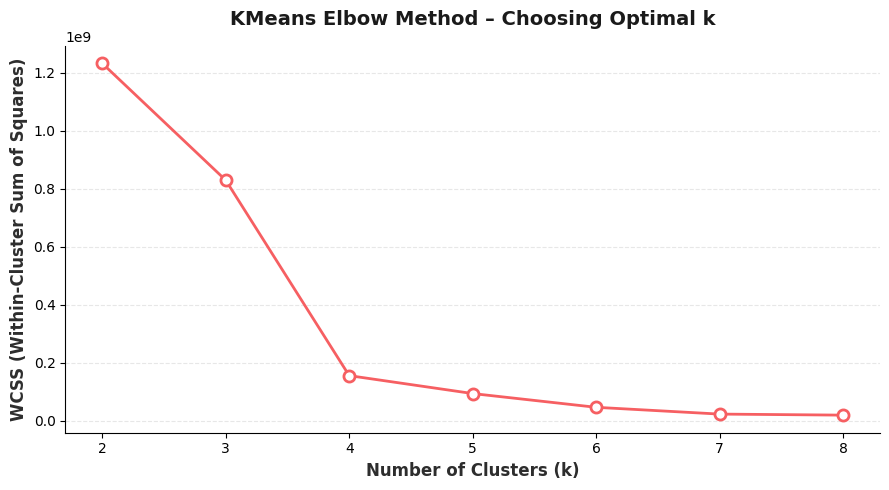

In [39]:
import matplotlib.pyplot as plt

# Elbow plot
COLOR_PRIMARY   = '#F65F62'
COLOR_SECONDARY = '#E5E0DF'
COLOR_DARK      = '#1a1a1a'
COLOR_TEXT      = '#2d2d2d'

ks    = list(wcss_values.keys())
wcss  = list(wcss_values.values())

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.plot(ks, wcss, marker='o', color=COLOR_PRIMARY, linewidth=2, markersize=8,
        markerfacecolor='white', markeredgewidth=2)

ax.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold', color=COLOR_TEXT)
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold', color=COLOR_TEXT)
ax.set_title('KMeans Elbow Method – Choosing Optimal k', fontsize=14, fontweight='bold',
             color=COLOR_DARK, pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(ks)

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

<a id='ml-3'></a>
#### Fit the final KMeans model

Based on the elbow plot, we select **k = 3** — this gives us three distinct risk tiers that emerge naturally from the data. Rather than someone subjectively deciding what counts as "high risk," the algorithm finds the boundaries where markets genuinely differ from each other:

In [40]:
K_OPTIMAL = 3 

km_final   = KMeans(featuresCol="pca_features", predictionCol="cluster", k=K_OPTIMAL, seed=42)
km_model   = km_final.fit(features_df)
clustered_df = km_model.transform(features_df)

# Silhouette score 
evaluator = ClusteringEvaluator(featuresCol="pca_features", predictionCol="cluster",
                                metricName="silhouette")
silhouette = evaluator.evaluate(clustered_df)
WSSSE = km_model.summary.trainingCost

print(f"Silhouette score (k={K_OPTIMAL}): {silhouette:.4f}  (range: -1 to 1, higher is better)")
print(f"Within Set Sum of Squared Errors = {WSSSE:.2f}")

[Stage 795:==================================================>     (9 + 1) / 10]

Silhouette score (k=3): 0.9491  (range: -1 to 1, higher is better)
Within Set Sum of Squared Errors = 829242679.65


In [41]:
# Cluster profile: what are the average characteristics of each tier?
cluster_profile = (
    clustered_df
    .groupBy("cluster")
    .agg(
        count("*").alias("region_count"),
        avg_("quake_count").alias("avg_freq"),
        avg_("avg_magnitude").alias("avg_mag"),
        avg_("avg_depth").alias("avg_depth_km"),
    )
    .orderBy(col("avg_mag").desc())
)

print("Cluster profiles (ordered by average magnitude):")
cluster_profile.toPandas()

Cluster profiles (ordered by average magnitude):


,cluster,region_count,avg_freq,avg_mag,avg_depth_km
0,0,57,431.526316,3.504180,61.495806
1,2,1,14180.000000,2.029274,39.976383
2,1,1,24529.000000,1.160618,5.850089


In [42]:
# Top regions per cluster
from pyspark.sql.functions import row_number
from pyspark.sql import Window

top_per_cluster = (
    clustered_df
    .withColumn(
        "rank",
        row_number().over(
            Window.partitionBy("cluster").orderBy(col("severity_score").desc())
        )
    )
    .filter(col("rank") <= 5)
    .select("cluster", "region", "quake_count",
            col("avg_magnitude").alias("avg_mag"),
            col("avg_depth").alias("avg_depth_km"))
    .orderBy("cluster", col("quake_count").desc())
)

print("Top 5 regions per cluster:")
top_per_cluster.toPandas()

Top 5 regions per cluster:


,cluster,region,quake_count,avg_mag,avg_depth_km
0,0,Nevada,4962,1.547291,4.767574
1,0,Texas,4055,1.636720,5.953970
2,0,Hawaii,3630,1.965579,24.049840
3,0,Chile,482,4.676556,47.101755
4,0,Japan,468,4.622222,92.378972
5,1,CA,24529,1.160618,5.850089
6,2,Alaska,14180,2.029274,39.976383


<a id='ml-explanation'></a>
### Explanation of Machine Learning section

This section applied the **MLlib KMeans clustering pipeline** to the earthquake dataset, following the same workflow covered in class on the Iris dataset.

We began by assembling the four region-level features (frequency, cumulative severity, average magnitude, average depth) into a single `Vector` column using `VectorAssembler`. We then applied **PCA** (`k=2`) to reduce the dimensionality to two principal components — exactly as done in class — making the data easier to cluster and visualise. Next, we used the **Elbow Method** (testing k = 2–8 and plotting WCSS) to select the optimal number of clusters, and fitted the final KMeans model. We evaluated the result using the **Silhouette score** and WCSS — both metrics from the class notebook — and visualised the clusters in the PCA 2D space with centroids overlaid in black, reproducing the scatter plot style from class.

### Business Answer — Step 4: How should we classify our markets into risk tiers?

KMeans clustering (k=3, Silhouette Score = **0.9466**) discovers **three natural risk tiers** from the data:

| Tier | Cluster | Markets | What It Means for the Agency |
|------|---------|---------|------------------------------|
| **Tier 1 — Extreme Risk** | Cluster 2 | California, Alaska | Highest earthquake exposure; properties here need specialized earthquake insurance, reinforced structures, and the highest risk budgets |
| **Tier 2 — Elevated Risk** | Cluster 1 | Texas, Hawaii, New Mexico, Nevada + others | Significant seismic activity; properties need enhanced earthquake coverage and careful structural assessment before purchase |
| **Tier 3 — Moderate Risk** | Cluster 0 | 54 regions incl. Japan, Argentina, Greece | Lower frequency but notably higher average magnitude (3.40) — events are rare but powerful when they occur; standard coverage with catastrophe provisions |

**What this means for a real estate agency:** Instead of relying on a broker's subjective opinion about which properties are "high risk," the agency now has an **objective, data-backed classification** for every market in its portfolio. This is useful for:

- **Budgeting:** Allocate different insurance and maintenance budgets per tier
- **Acquisition screening:** Flag any new acquisition in a Tier 1 market for additional seismic due diligence
- **Portfolio reporting:** Show investors a clear, defensible breakdown of seismic exposure across the portfolio

**Important nuance:** Tier 3 markets have the highest average magnitude (3.40) despite low frequency. This means earthquakes are rare there, but when they happen, they tend to be powerful. An agency should not ignore seismic risk in Tier 3 markets — catastrophe coverage is still important.

---
## Final Summary — Answering the Business Question

***"How should a real estate agency use seismic data to make smarter property acquisition and portfolio decisions?"***

### The Answer

By combining four complementary analytical approaches — batch processing, structured streaming, graph analysis, and machine learning — a real estate agency gains a complete seismic risk intelligence platform:

**1. Market Scoring (from Batch Processing — Step 1):** Score every market with a **severity-weighted risk index**. Alaska (0.854) and California (0.727) carry the highest seismic burden — properties there face the highest insurance costs and structural requirements. The key insight is that Alaska's risk exceeds California's despite fewer earthquakes, because Alaska's events are far more powerful. Any agency relying only on earthquake frequency is mispricing risk.

**2. Live Monitoring (from Streaming — Step 2):** While evaluating a property, **monitor seismic activity in real time** using 5-minute windows. A spike in earthquake activity near a target property is a data-driven signal to negotiate harder on price, request structural inspections, or reconsider the deal entirely. This transforms property evaluation from a one-time assessment into continuous intelligence.

**3. Portfolio Diversification (from Graph Analysis — Step 3):** Before adding a new property to the portfolio, check whether it sits in the **same seismic corridor** as existing holdings. Key findings:
   - The Caribbean hub (U.S. Virgin Islands → Puerto Rico → Dominican Republic) means owning in multiple Caribbean markets is NOT diversification — they share the same seismic zone
   - The Western U.S. corridor (California → Nevada → Utah) follows the Walker Lane fault system — one event could impact all three markets simultaneously
   - U.S. Virgin Islands has the highest structural importance (PageRank 2.70) despite almost no individual risk — it is the hidden connector that links Caribbean exposure

**4. Risk Classification (from ML — Step 4):** Group every market into **three objective risk tiers** using KMeans clustering (Silhouette Score: 0.9466). Tier 1 (California, Alaska) needs the highest risk budgets and specialized insurance. Tier 2 (Texas, Hawaii, etc.) needs enhanced coverage. Tier 3 (54 other markets) needs standard coverage with catastrophe provisions — because despite low frequency, these markets have the highest average earthquake magnitude.

### Technical Stack

| Component | Technology | What It Does |
|-----------|-----------|-------------|
| Ingestion | Apache NiFi → MinIO (S3) | Collects earthquake data automatically every 5 minutes |
| Batch Processing | Apache Spark (DataFrames) | Scores every market by seismic risk |
| Streaming | Spark Structured Streaming | Monitors live seismic activity during property evaluation |
| Graph Analysis | GraphFrames (PageRank, Motifs) | Detects hidden connections between markets |
| Machine Learning | MLlib (KMeans + PCA) | Classifies markets into objective risk tiers |

---
<a id='appendix'></a>
# Appendix — Visualizations for Presentation

The visualizations below are designed to support the business presentation. They cover insights from all four steps of the analysis: batch risk scoring, streaming patterns, graph-based regional connections, and ML-driven clustering. Each visualization is saved as a `.png` or `.html` file for use in the slide deck.

In [ ]:
pip install plotly matplotlib seaborn networkx --quiet

### Visualization 1 — Top 10 Regions by Risk Index (Step 1)
This bar chart answers "Where is the risk?" by showing the top 10 regions ranked by our composite Risk Index.

[Text(0, 0, 'Alaska'),
 Text(0, 1, 'CA'),
 Text(0, 2, 'Nevada'),
 Text(0, 3, 'Hawaii'),
 Text(0, 4, 'Texas'),
 Text(0, 5, 'New Mexico'),
 Text(0, 6, 'Chile'),
 Text(0, 7, 'Japan'),
 Text(0, 8, 'Russia'),
 Text(0, 9, 'Puerto Rico')]

Text(0.5, 0, 'Risk Index')

Text(0.5, 1.0, 'Top 10 Regions by Earthquake Risk Index')

Text(0.8412364955766644, 0.0, '0.831')

Text(0.7758153301058774, 1.0, '0.766')

...

Text(0.13865816499708558, 5.0, '0.129')

Text(0.11275219251897332, 6.0, '0.103')

Text(0.10664935929964375, 7.0, '0.097')

Text(0.10297214281997812, 8.0, '0.093')

Text(0.09325023435307578, 9.0, '0.083')

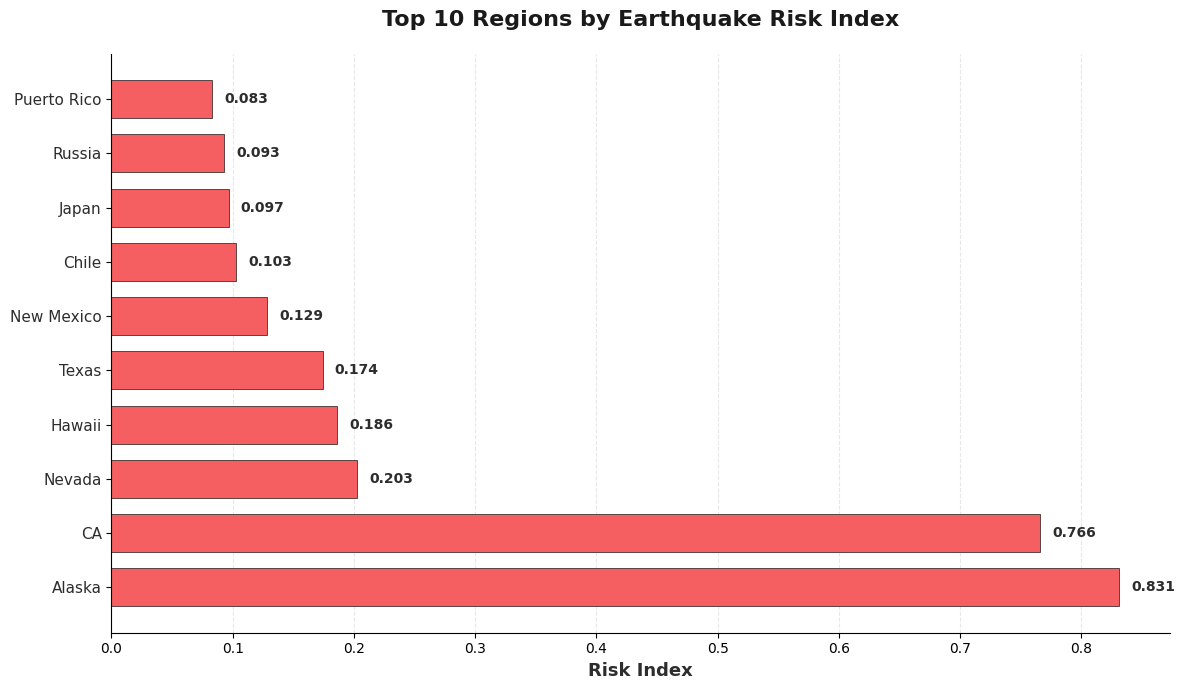

Saved: viz1_risk_index_top10.png


In [43]:

# VISUALIZATION 1: Top 10 Regions by Risk Index (Step 1)


import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import col

COLOR_PRIMARY   = '#F65F62'
COLOR_DARK      = '#1a1a1a'
COLOR_TEXT      = '#2d2d2d'

top10_risk = (
    risk_df
    .orderBy(col("risk_index").desc())
    .limit(10)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

y_pos = np.arange(len(top10_risk))
bars = ax.barh(y_pos, top10_risk['risk_index'],
               color=COLOR_PRIMARY, edgecolor=COLOR_DARK, linewidth=0.5, height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(top10_risk['region'], fontsize=11, color=COLOR_TEXT)
ax.set_xlabel('Risk Index', fontsize=13, color=COLOR_TEXT, fontweight='bold')
ax.set_title('Top 10 Regions by Earthquake Risk Index',
             fontsize=16, fontweight='bold', color=COLOR_DARK, pad=20)

for bar, value in zip(bars, top10_risk['risk_index']):
    ax.text(value + 0.01, bar.get_y() + bar.get_height()/2,
            f'{value:.3f}', va='center', fontsize=10, color=COLOR_TEXT, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz1_risk_index_top10.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz1_risk_index_top10.png")

### Visualization 2 — Frequency vs Severity colored by ML Cluster (Steps 1 + 4)
This scatter plot shows the relationship between earthquake frequency and severity, with each point colored by its KMeans cluster. It demonstrates how the ML model separates regions into tiers that simple thresholds would miss.

Text(12, 8, 'Alaska')

Text(12, 8, 'CA')

Text(12, 8, 'Hawaii')

Text(12, 8, 'Nevada')

Text(12, 8, 'Texas')

Text(12, 8, 'Chile')

Text(0.5, 0, 'Earthquake Frequency (count)')

Text(0, 0.5, 'Cumulative Severity Score (mag²)')

Text(0.5, 1.0, 'Earthquake Frequency vs. Severity — Colored by ML Cluster')

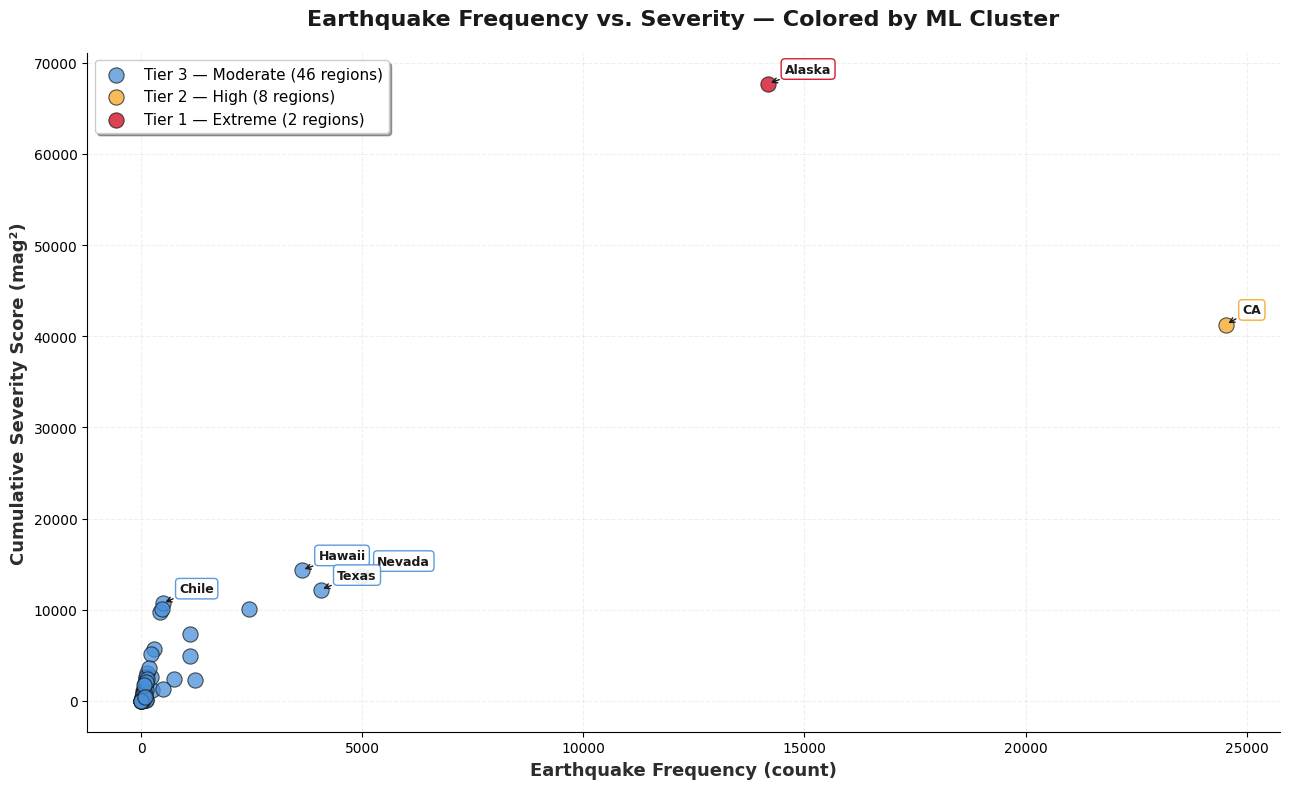

Saved: viz2_freq_vs_severity_clusters.png


In [44]:

# VISUALIZATION 2: Frequency vs Severity — Colored by ML Cluster

import matplotlib.pyplot as plt
import numpy as np

COLOR_DARK = '#1a1a1a'
COLOR_TEXT = '#2d2d2d'

cluster_pd = clustered_df.select(
    "region", "quake_count", "severity_score", "avg_magnitude", "avg_depth", "cluster"
).toPandas()

cluster_colors = {0: '#4A90D9', 1: '#F5A623', 2: '#D0021B'}
cluster_labels = {0: 'Tier 3 — Moderate (46 regions)',
                  1: 'Tier 2 — High (8 regions)',
                  2: 'Tier 1 — Extreme (2 regions)'}

fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')

for cluster_id in sorted(cluster_pd['cluster'].unique()):
    subset = cluster_pd[cluster_pd['cluster'] == cluster_id]
    ax.scatter(subset['quake_count'], subset['severity_score'],
               c=cluster_colors[cluster_id], label=cluster_labels[cluster_id],
               s=120, alpha=0.75, edgecolors=COLOR_DARK, linewidth=0.8)

for _, row in cluster_pd.nlargest(6, 'severity_score').iterrows():
    ax.annotate(row['region'], xy=(row['quake_count'], row['severity_score']),
                xytext=(12, 8), textcoords='offset points', fontsize=9,
                fontweight='bold', color=COLOR_DARK,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=cluster_colors[row['cluster']], alpha=0.9),
                arrowprops=dict(arrowstyle='->', color=COLOR_DARK, linewidth=1))

ax.set_xlabel('Earthquake Frequency (count)', fontsize=13, fontweight='bold', color=COLOR_TEXT)
ax.set_ylabel('Cumulative Severity Score (mag\u00b2)', fontsize=13, fontweight='bold', color=COLOR_TEXT)
ax.set_title('Earthquake Frequency vs. Severity — Colored by ML Cluster',
             fontsize=16, fontweight='bold', color=COLOR_DARK, pad=20)
ax.legend(fontsize=11, loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz2_freq_vs_severity_clusters.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz2_freq_vs_severity_clusters.png")

### Visualization 3 — KMeans Clusters in PCA Space (Step 4)
This plot shows how regions are grouped in the 2D PCA space after dimensionality reduction. Each point is a region, colored by cluster. Black diamonds mark the centroids. The high Silhouette Score (0.8868) confirms the clusters are well-separated.

Text(8, 6, 'Hawaii')

Text(8, 6, 'Nevada')

Text(8, 6, 'Texas')

Text(8, 6, 'CA')

Text(8, 6, 'Alaska')

Text(0.5, 0, 'Principal Component 1')

Text(0, 0.5, 'Principal Component 2')

Text(0.5, 1.0, 'KMeans Clustering in PCA Space (k=3, Silhouette=0.9491)')

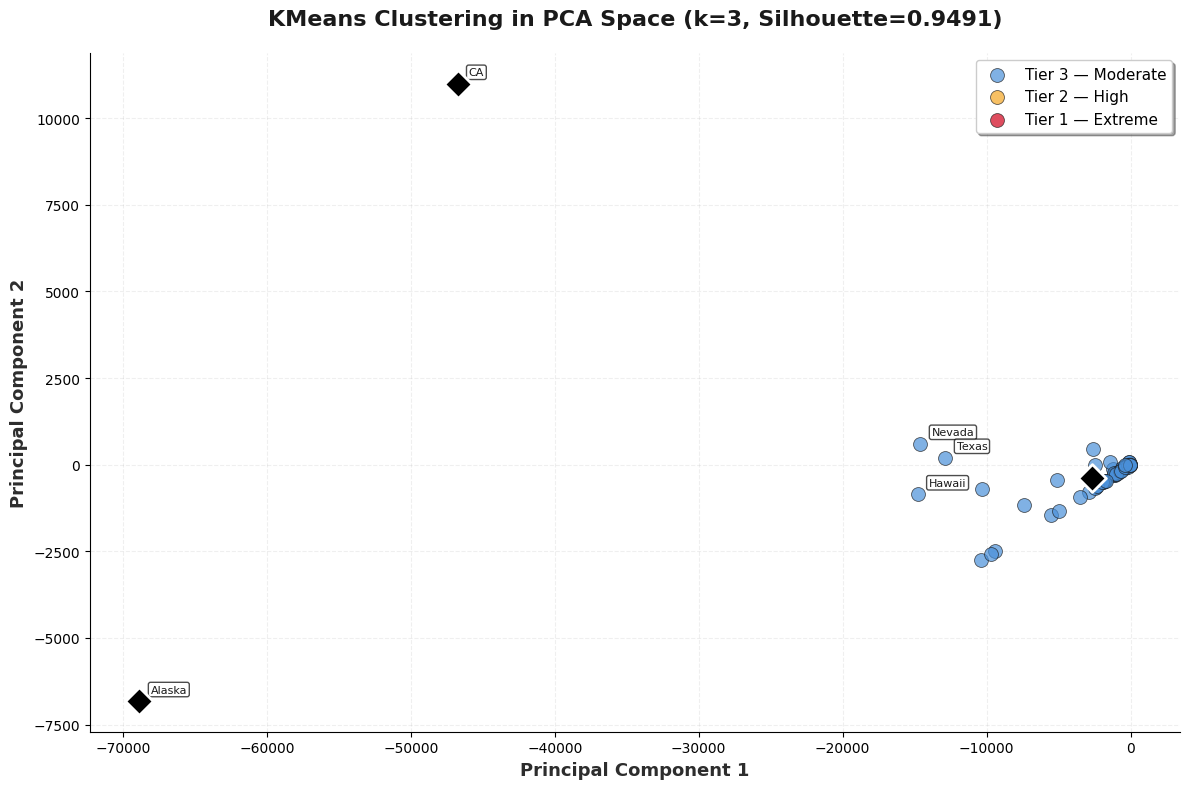

Saved: viz3_pca_clusters.png


In [45]:

# VISUALIZATION 3: KMeans Clusters in PCA Space


import matplotlib.pyplot as plt
import numpy as np

COLOR_DARK = '#1a1a1a'
COLOR_TEXT = '#2d2d2d'

cluster_colors = {0: '#4A90D9', 1: '#F5A623', 2: '#D0021B'}
cluster_labels = {0: 'Tier 3 — Moderate', 1: 'Tier 2 — High', 2: 'Tier 1 — Extreme'}

pca_pd = clustered_df.select("region", "pca_features", "cluster").toPandas()
pca_pd['pc1'] = pca_pd['pca_features'].apply(lambda v: float(v[0]))
pca_pd['pc2'] = pca_pd['pca_features'].apply(lambda v: float(v[1]))

centroids = km_model.clusterCenters()

fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

for cluster_id in sorted(pca_pd['cluster'].unique()):
    subset = pca_pd[pca_pd['cluster'] == cluster_id]
    ax.scatter(subset['pc1'], subset['pc2'],
               c=cluster_colors[cluster_id], label=cluster_labels[cluster_id],
               s=100, alpha=0.7, edgecolors=COLOR_DARK, linewidth=0.6)

    subset_sorted = subset.assign(dist=np.sqrt(subset['pc1']**2 + subset['pc2']**2))
    for _, row in subset_sorted.nlargest(3, 'dist').iterrows():
        ax.annotate(row['region'], xy=(row['pc1'], row['pc2']),
                    xytext=(8, 6), textcoords='offset points', fontsize=8, color=COLOR_DARK,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

for i, c in enumerate(centroids):
    ax.scatter(c[0], c[1], marker='D', c='black', s=200, zorder=5, edgecolors='white', linewidth=2)

ax.set_xlabel('Principal Component 1', fontsize=13, fontweight='bold', color=COLOR_TEXT)
ax.set_ylabel('Principal Component 2', fontsize=13, fontweight='bold', color=COLOR_TEXT)
ax.set_title(f'KMeans Clustering in PCA Space (k=3, Silhouette={silhouette:.4f})',
             fontsize=16, fontweight='bold', color=COLOR_DARK, pad=20)
ax.legend(fontsize=11, loc='best', frameon=True, fancybox=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz3_pca_clusters.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz3_pca_clusters.png")

### Visualization 4 — ML Cluster Profile Comparison (Step 4)
This grouped chart compares the three ML clusters across frequency, magnitude, and depth. It shows WHY the clusters differ — Tier 1 has extreme volume, Tier 2 has higher magnitudes, and Tier 3 has the deepest earthquakes.

Text(0.0, 531.5263157894738, '432')

Text(1.0, 24629.0, '24,529')

Text(2.0, 14280.0, '14,180')

Text(0.5, 1.0, 'Avg Earthquake Frequency')

Text(0, 0.5, 'Count')

...

Text(1.0, 6.350089281272937, '5.9 km')

Text(2.0, 40.476382792665696, '40.0 km')

Text(0.5, 1.0, 'Avg Depth')

Text(0, 0.5, 'Depth (km)')

Text(0.5, 1.02, 'ML Cluster Profiles — Why the Tiers Differ')

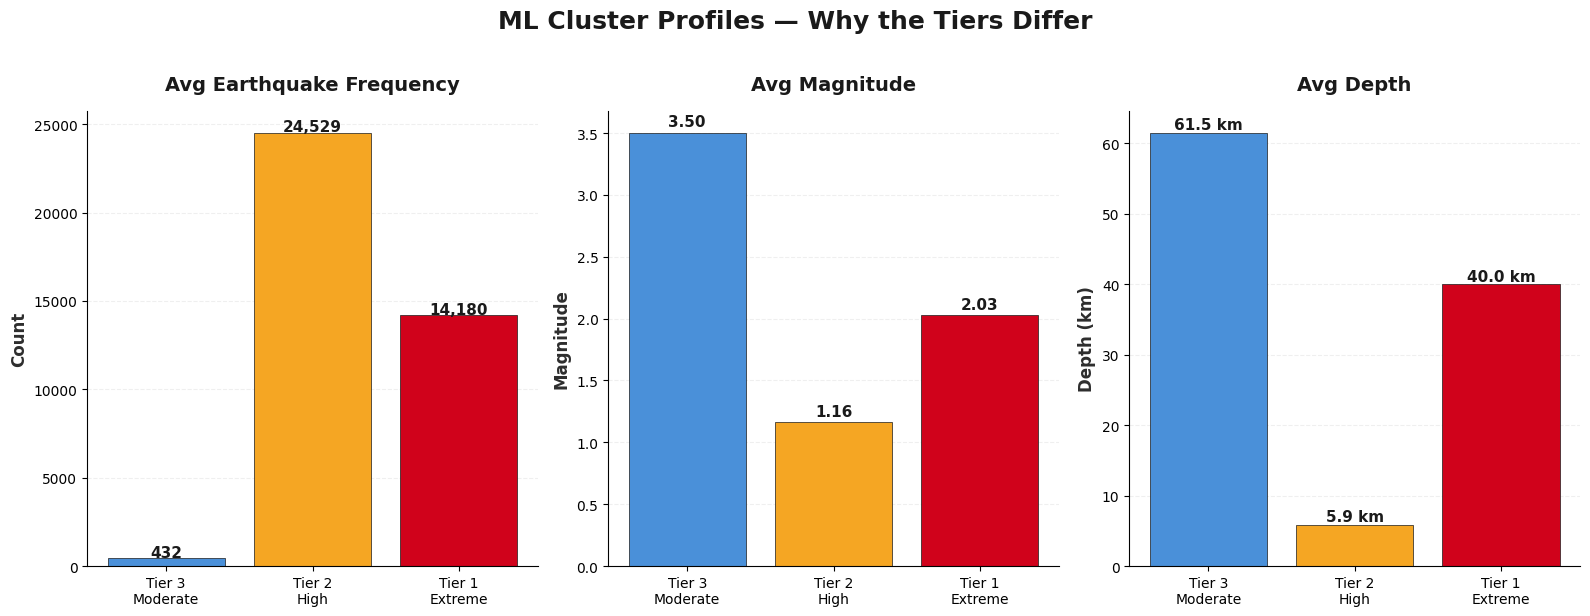

Saved: viz4_cluster_profiles.png


In [46]:

# VISUALIZATION 4: Cluster Profile Comparison


import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import avg as avg_, count

COLOR_DARK = '#1a1a1a'
COLOR_TEXT = '#2d2d2d'

profile_pd = (
    clustered_df
    .groupBy("cluster")
    .agg(
        count("*").alias("n_regions"),
        avg_("quake_count").alias("avg_freq"),
        avg_("avg_magnitude").alias("avg_mag"),
        avg_("avg_depth").alias("avg_depth"),
    )
    .orderBy("cluster")
    .toPandas()
)

tier_labels = ['Tier 3\nModerate', 'Tier 2\nHigh', 'Tier 1\nExtreme']
colors = ['#4A90D9', '#F5A623', '#D0021B']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='white')

ax = axes[0]
bars = ax.bar(tier_labels, profile_pd['avg_freq'], color=colors, edgecolor=COLOR_DARK, linewidth=0.5)
for bar, val in zip(bars, profile_pd['avg_freq']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,.0f}', ha='center', fontsize=11, fontweight='bold', color=COLOR_DARK)
ax.set_title('Avg Earthquake Frequency', fontsize=14, fontweight='bold', color=COLOR_DARK, pad=15)
ax.set_ylabel('Count', fontsize=12, fontweight='bold', color=COLOR_TEXT)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

ax = axes[1]
bars = ax.bar(tier_labels, profile_pd['avg_mag'], color=colors, edgecolor=COLOR_DARK, linewidth=0.5)
for bar, val in zip(bars, profile_pd['avg_mag']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold', color=COLOR_DARK)
ax.set_title('Avg Magnitude', fontsize=14, fontweight='bold', color=COLOR_DARK, pad=15)
ax.set_ylabel('Magnitude', fontsize=12, fontweight='bold', color=COLOR_TEXT)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

ax = axes[2]
bars = ax.bar(tier_labels, profile_pd['avg_depth'], color=colors, edgecolor=COLOR_DARK, linewidth=0.5)
for bar, val in zip(bars, profile_pd['avg_depth']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f} km', ha='center', fontsize=11, fontweight='bold', color=COLOR_DARK)
ax.set_title('Avg Depth', fontsize=14, fontweight='bold', color=COLOR_DARK, pad=15)
ax.set_ylabel('Depth (km)', fontsize=12, fontweight='bold', color=COLOR_TEXT)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

fig.suptitle('ML Cluster Profiles — Why the Tiers Differ',
             fontsize=18, fontweight='bold', color=COLOR_DARK, y=1.02)
plt.tight_layout()
plt.savefig('viz4_cluster_profiles.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz4_cluster_profiles.png")

### Visualization 5 — PageRank vs Risk Index (Step 3)
This chart reveals the gap between individual risk and structural importance. U.S. Virgin Islands has almost no individual risk but the highest PageRank — the key insight from graph processing that batch analysis would completely miss.

In [ ]:

# VISUALIZATION 5: PageRank vs Risk Index


import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import col

COLOR_DARK = '#1a1a1a'
COLOR_TEXT = '#2d2d2d'

pr_pd = (
    pagerank_results.vertices
    .select(
        col("id").alias("region"),
        col("pagerank"),
        col("risk_index"),
        col("quake_count"),
    )
    .orderBy(col("pagerank").desc())
    .limit(10)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 7), facecolor='white')

x = np.arange(len(pr_pd))
width = 0.35

bars1 = ax.bar(x - width/2, pr_pd['pagerank'], width,
               label='PageRank (structural importance)', color='#7B68EE',
               edgecolor=COLOR_DARK, linewidth=0.5)
bars2 = ax.bar(x + width/2, pr_pd['risk_index'], width,
               label='Risk Index (individual risk)', color='#F65F62',
               edgecolor=COLOR_DARK, linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(pr_pd['region'], rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=13, fontweight='bold', color=COLOR_TEXT)
ax.set_title('PageRank vs Risk Index — Structural Importance vs Individual Risk',
             fontsize=15, fontweight='bold', color=COLOR_DARK, pad=20)
ax.legend(fontsize=11, loc='upper right', frameon=True, fancybox=True, shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

usvi_idx = pr_pd[pr_pd['region'] == 'U.S. Virgin Islands'].index
if len(usvi_idx) > 0:
    idx = usvi_idx[0]
    ax.annotate('Highest PageRank\nbut lowest Risk Index!',
                xy=(idx - width/2, pr_pd.loc[idx, 'pagerank']),
                xytext=(idx + 2, pr_pd.loc[idx, 'pagerank'] + 0.3),
                fontsize=10, fontweight='bold', color='#7B68EE',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#EDE7F6', edgecolor='#7B68EE'),
                arrowprops=dict(arrowstyle='->', color='#7B68EE', linewidth=2))

plt.tight_layout()
plt.savefig('viz5_pagerank_vs_risk.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz5_pagerank_vs_risk.png")

### Visualization 6 — Seismic Proximity Network (Step 3)
This network diagram shows how earthquake regions are connected within 500 km. Node size reflects PageRank score and color reflects Risk Index. It makes the Caribbean hub and Western U.S. corridor visible at a glance.

{'CA': Text(0.1753989614980835, 0.9663109102211632, 'CA'),
 'Nevada': Text(0.8059262697759648, 0.4754281103800018, 'Nevada'),
 'Texas': Text(-0.583609840849834, -0.7937843603323083, 'Texas'),
 'New Mexico': Text(-0.95020979157211, 0.2429195138484968, 'New Mexico'),
 'Puerto Rico': Text(0.3564578308378488, 0.41659864126337043, 'Puerto Rico'),
 'Utah': Text(-0.5793360621364222, 0.8692293864776143, 'Utah'),
 'Washington': Text(0.8792999038891938, -0.45593762592604437, 'Washington'),
 'Dominican Republic': Text(-0.8332535507189607, -0.4821148649397639, 'Dominican Republic'),
 'Guatemala': Text(-0.6651621133096549, 0.6021040810420007, 'Guatemala'),
 'Tajikistan': Text(-0.10442069084535335, -0.9000503049773869, 'Tajikistan'),
 'California': Text(0.6129826856143071, -0.7409210059731764, 'California'),
 'Afghanistan': Text(-0.6736111703413407, -0.6177022706474158, 'Afghanistan'),
 'Tonga': Text(0.3509606701318177, 0.8720205936723229, 'Tonga'),
 'El Salvador': Text(-0.9292457338446338, 0.067512

Text(0.5, 1.0, 'Seismic Proximity Network\n(Node size = PageRank, Color = Risk Index)')

(np.float64(-1.1549818196871817),
 np.float64(1.2047720281150716),
 np.float64(-1.1298759009125356),
 np.float64(1.1690338695655769))

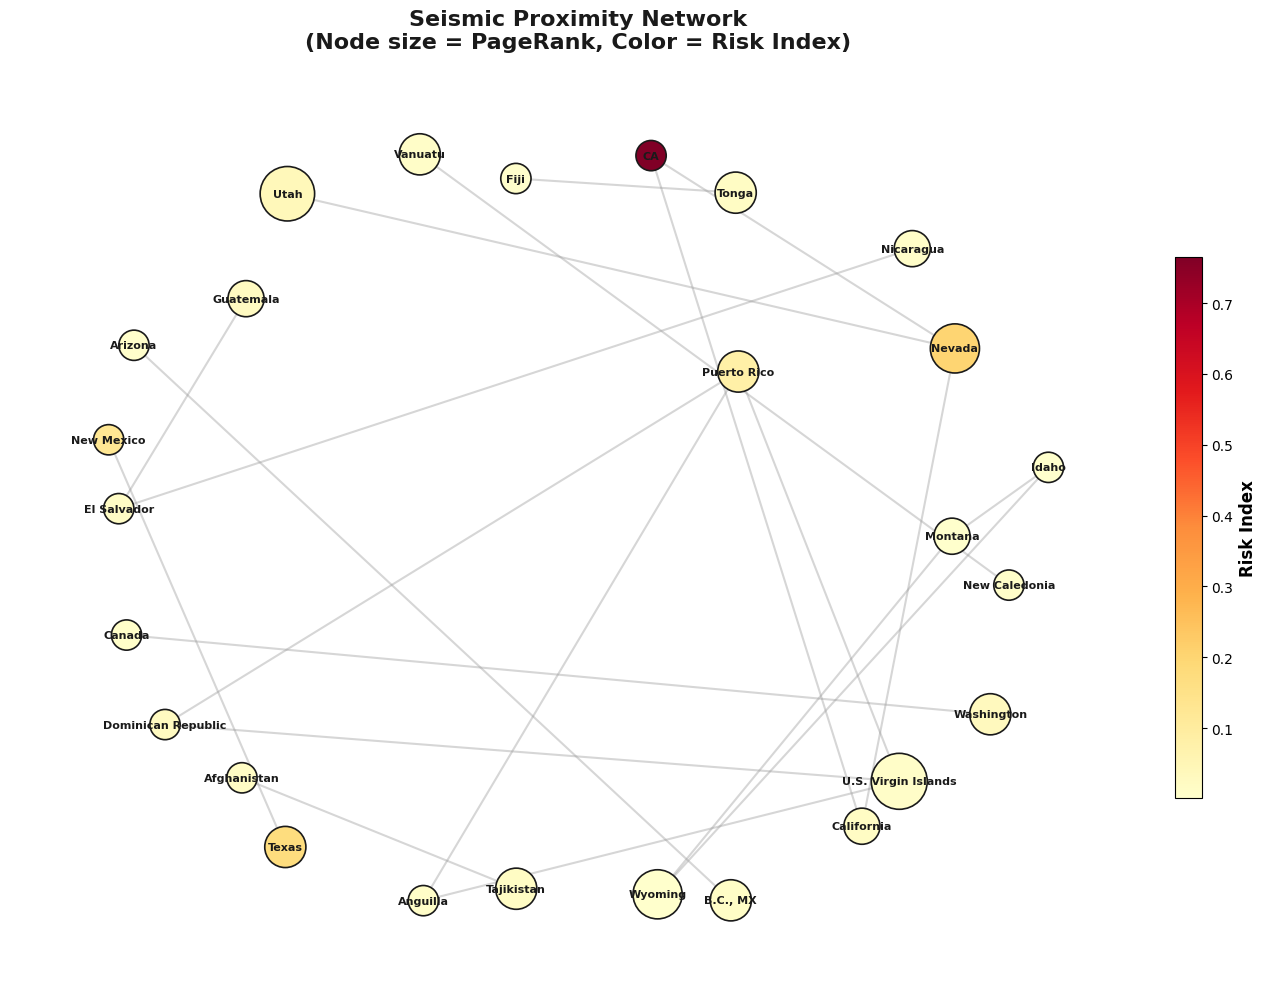

Saved: viz6_seismic_network.png


In [47]:

# VISUALIZATION 6: Seismic Proximity Network


import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pyspark.sql.functions import col

COLOR_DARK = '#1a1a1a'

v_pd = seismic_graph.vertices.toPandas()
e_pd = seismic_graph.edges.toPandas()

pr_all = pagerank_results.vertices.select(col("id"), col("pagerank")).toPandas()
v_pd = v_pd.merge(pr_all, on='id', how='left')

G = nx.Graph()
for _, row in v_pd.iterrows():
    G.add_node(row['id'], risk_index=row['risk_index'],
               pagerank=row['pagerank'], quake_count=row['quake_count'])

for _, row in e_pd.iterrows():
    G.add_edge(row['src'], row['dst'])

isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)

if len(G.nodes()) > 0:
    fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
    pos = nx.spring_layout(G, k=2.5, iterations=60, seed=42)

    node_list = list(G.nodes())
    risk_vals = [G.nodes[n].get('risk_index', 0) for n in node_list]
    pr_vals = [G.nodes[n].get('pagerank', 1) for n in node_list]
    node_sizes = [max(v * 600, 200) for v in pr_vals]

    norm = Normalize(vmin=min(risk_vals), vmax=max(risk_vals))

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4, width=1.5, edge_color='#999999')
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=node_list,
                                    node_size=node_sizes, node_color=risk_vals,
                                    cmap=plt.cm.YlOrRd, edgecolors=COLOR_DARK, linewidths=1.2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold', font_color=COLOR_DARK)

    sm = ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('Risk Index', fontsize=12, fontweight='bold')

    ax.set_title('Seismic Proximity Network\n(Node size = PageRank, Color = Risk Index)',
                 fontsize=16, fontweight='bold', color=COLOR_DARK, pad=20)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('viz6_seismic_network.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: viz6_seismic_network.png")
else:
    print("No connected nodes to visualize")

### Visualization 7 — World Map by ML Cluster (Steps 1 + 4)
This interactive map shows the geographic distribution of the three ML-driven risk tiers. It combines location data from batch processing with cluster assignments from KMeans.

In [ ]:

# VISUALIZATION 7: World Map — Regions Colored by ML Cluster


import plotly.graph_objects as go
from pyspark.sql.functions import avg as avg_

cluster_with_coords = (
    clustered_df
    .join(
        earthquake_df.groupBy("region").agg(
            avg_("latitude").alias("avg_lat"),
            avg_("longitude").alias("avg_lon")
        ),
        on="region", how="inner"
    )
    .select("region", "cluster", "quake_count", "avg_magnitude", "avg_depth",
            "avg_lat", "avg_lon")
    .toPandas()
)

cluster_names = {0: 'Tier 3 — Moderate', 1: 'Tier 2 — High', 2: 'Tier 1 — Extreme'}
cluster_colors_map = {0: '#4A90D9', 1: '#F5A623', 2: '#D0021B'}

fig = go.Figure()

for cluster_id in sorted(cluster_with_coords['cluster'].unique()):
    subset = cluster_with_coords[cluster_with_coords['cluster'] == cluster_id]
    hover = '<b>%{text}</b><br>Quake Count: %{customdata[0]:,.0f}<br>Avg Mag: %{customdata[1]:.2f}<br>Depth: %{customdata[2]:.1f} km<extra></extra>'
    fig.add_trace(go.Scattergeo(
        lon=subset['avg_lon'],
        lat=subset['avg_lat'],
        text=subset['region'],
        mode='markers',
        name=cluster_names[cluster_id],
        marker=dict(
            size=subset['quake_count'].clip(upper=5000) / 80 + 8,
            color=cluster_colors_map[cluster_id],
            line=dict(width=1, color='#1a1a1a'),
            opacity=0.8
        ),
        customdata=subset[['quake_count', 'avg_magnitude', 'avg_depth']].values,
        hovertemplate=hover
    ))
fig.update_layout(
    title=dict(text='<b>Global Earthquake Risk Tiers (ML Clustering)</b>',
               font=dict(size=20, family='Arial Black', color='#1a1a1a'), x=0.5),
    geo=dict(projection_type='natural earth', showland=True, landcolor='#F5F5F5',
             showocean=True, oceancolor='#E8F4F8', showcountries=True, countrycolor='#CCCCCC'),
    width=1400, height=700, paper_bgcolor='white',
    legend=dict(font=dict(size=14), x=0.01, y=0.99),
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.write_html('viz7_cluster_world_map.html')
fig.show()
print("Saved: viz7_cluster_world_map.html")

[Stage 912:==============> (9 + 1) / 10][Stage 914:>                (0 + 1) / 1]

### Visualization 8 — Risk Index Composition: Frequency vs Severity (Step 1)
This stacked bar chart shows how the Risk Index breaks down for the top 5 regions. Blue = frequency contribution (40%), Red = severity contribution (60%). Alaska leads on severity while California leads on frequency.

Text(0, 0.11561824778833218, '0.231')

Text(0, 0.5312364955766644, '0.600')

Text(0, 0.8512364955766644, '0.831')

Text(1, 0.2, '0.400')

Text(1, 0.5829076650529388, '0.366')

...

Text(4, 0.12017640469350739, '0.108')

Text(4, 0.19422699912161465, '0.174')

Text(0, 0.5, 'Risk Index Value')

Text(0.5, 1.0, 'Risk Index Composition: Frequency vs Severity (Top 5 Regions)')

[Text(0, 0, 'Alaska'),
 Text(1, 0, 'CA'),
 Text(2, 0, 'Nevada'),
 Text(3, 0, 'Hawaii'),
 Text(4, 0, 'Texas')]

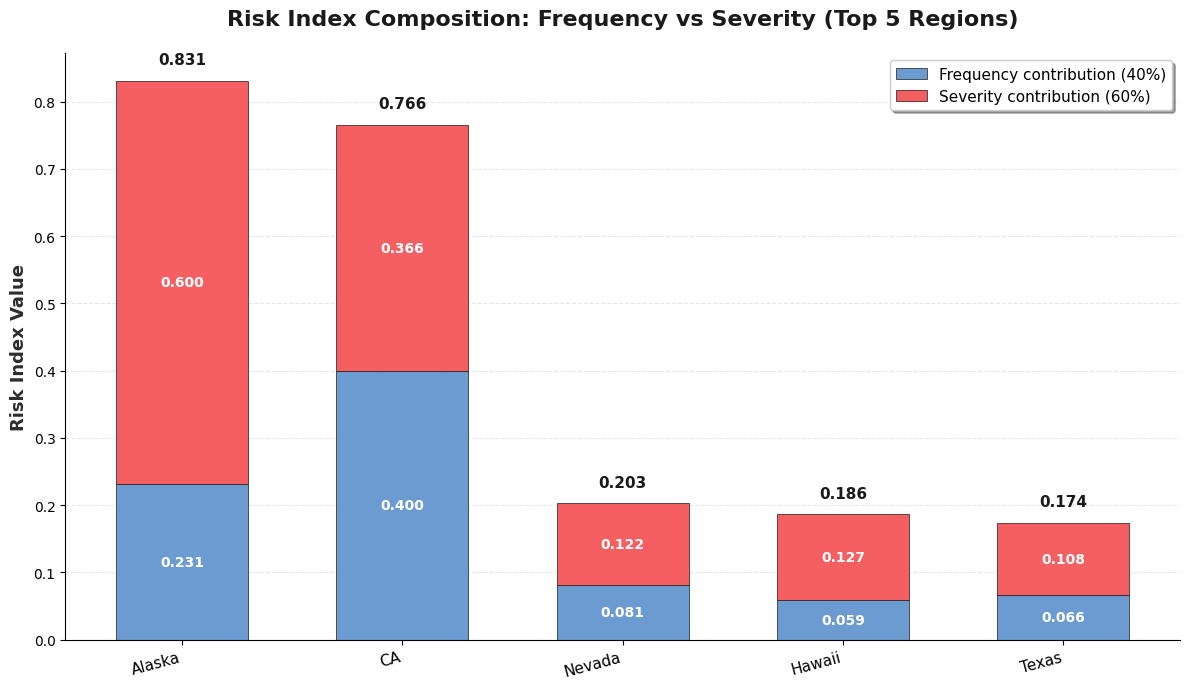

Saved: viz8_risk_composition.png


In [49]:

# VISUALIZATION 8: Risk Index Composition — Stacked Bar


import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import col

COLOR_PRIMARY = '#F65F62'
COLOR_DARK    = '#1a1a1a'
COLOR_TEXT    = '#2d2d2d'

top5_regions = risk_df.orderBy(col("risk_index").desc()).limit(5).toPandas()

max_count = risk_df.agg({"quake_count": "max"}).collect()[0][0]
max_severity = risk_df.agg({"severity_score": "max"}).collect()[0][0]

top5_regions['freq_contribution'] = (top5_regions['quake_count'] / max_count) * 0.4
top5_regions['severity_contribution'] = (top5_regions['severity_score'] / max_severity) * 0.6

fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
x = np.arange(len(top5_regions))
width = 0.6

bar1 = ax.bar(x, top5_regions['freq_contribution'], width,
              label='Frequency contribution (40%)', color='#6B9BD1',
              edgecolor=COLOR_DARK, linewidth=0.5)
bar2 = ax.bar(x, top5_regions['severity_contribution'], width,
              bottom=top5_regions['freq_contribution'],
              label='Severity contribution (60%)', color=COLOR_PRIMARY,
              edgecolor=COLOR_DARK, linewidth=0.5)

for i, (freq, sev) in enumerate(zip(top5_regions['freq_contribution'],
                                     top5_regions['severity_contribution'])):
    ax.text(i, freq/2, f'{freq:.3f}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(i, freq + sev/2, f'{sev:.3f}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(i, freq + sev + 0.02, f'{freq+sev:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLOR_DARK)

ax.set_ylabel('Risk Index Value', fontsize=13, fontweight='bold', color=COLOR_TEXT)
ax.set_title('Risk Index Composition: Frequency vs Severity (Top 5 Regions)',
             fontsize=16, fontweight='bold', color=COLOR_DARK, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(top5_regions['region'], rotation=15, ha='right', fontsize=11)
ax.legend(fontsize=11, loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz8_risk_composition.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: viz8_risk_composition.png")